In [1]:

# imports and load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

# Load the ML-ready dataset from Week 1
df = pd.read_csv('data/processed/telco_churn_features.csv')

print(f"Dataset loaded: {df.shape}")
print(f"Churn rate    : {df['Churn'].mean()*100:.1f}%")
print(f"\nAll columns:")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")

Dataset loaded: (7043, 24)
Churn rate    : 26.5%

All columns:
  gender: int64
  SeniorCitizen: int64
  Partner: int64
  Dependents: int64
  tenure: int64
  PhoneService: int64
  MultipleLines: int64
  InternetService: str
  OnlineSecurity: int64
  OnlineBackup: int64
  DeviceProtection: int64
  TechSupport: int64
  StreamingTV: int64
  StreamingMovies: int64
  Contract: str
  PaperlessBilling: int64
  PaymentMethod: str
  MonthlyCharges: float64
  TotalCharges: float64
  Churn: int64
  numServices: int64
  chargePerMonth: float64
  tenureBucket: str
  contractRisk: int64


In [2]:
# separate features (X) and target (y)

# Drop target column to get features
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nTarget distribution:")
print(f"  Not churned (0): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"  Churned     (1): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")

Features shape : (7043, 23)
Target shape   : (7043,)

Target distribution:
  Not churned (0): 5174 (73.5%)
  Churned     (1): 1869 (26.5%)


In [3]:
#  identify which columns need which preprocessing

# Numerical columns — need StandardScaler
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
                  'numServices', 'chargePerMonth', 'contractRisk']

# Categorical columns — need OneHotEncoder
categorical_cols = ['InternetService', 'Contract',
                    'PaymentMethod', 'tenureBucket']

# Binary columns — already 0/1, no preprocessing needed
binary_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
               'PhoneService', 'MultipleLines', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

print("Numerical cols  (StandardScaler)  :", numerical_cols)
print("\nCategorical cols (OneHotEncoder)  :", categorical_cols)
print("\nBinary cols      (passthrough)    :", binary_cols)

# Verify all columns are accounted for
all_cols = numerical_cols + categorical_cols + binary_cols
missing = [c for c in X.columns if c not in all_cols]
print(f"\nUnaccounted columns: {missing}")
print("(Should be empty list [])")

Numerical cols  (StandardScaler)  : ['tenure', 'MonthlyCharges', 'TotalCharges', 'numServices', 'chargePerMonth', 'contractRisk']

Categorical cols (OneHotEncoder)  : ['InternetService', 'Contract', 'PaymentMethod', 'tenureBucket']

Binary cols      (passthrough)    : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

Unaccounted columns: []
(Should be empty list [])


In [4]:
#  split data 80/20 with stratification
# stratify=y ensures both splits have same churn rate (26.5%)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          
)

print("Train/Test Split Results:")
print(f"{'':20} {'Count':>8} {'Churn Rate':>12}")
print("-" * 42)
print(f"{'Training set':20} {len(X_train):>8} {y_train.mean()*100:>11.1f}%")
print(f"{'Test set':20} {len(X_test):>8}  {y_test.mean()*100:>11.1f}%")
print(f"{'Full dataset':20} {len(X):>8}  {y.mean()*100:>11.1f}%")
print("-" * 42)
print("\nChurn rates are equal in both splits — stratification worked!")

Train/Test Split Results:
                        Count   Churn Rate
------------------------------------------
Training set             5634        26.5%
Test set                 1409         26.5%
Full dataset             7043         26.5%
------------------------------------------

Churn rates are equal in both splits — stratification worked!


In [5]:
#  build sklearn ColumnTransformer
# This applies different preprocessing to different column types

# StandardScaler: normalises numerical cols to mean=0, std=1
# OneHotEncoder : converts text categories to binary columns
# passthrough    : binary cols passed as-is (already 0/1)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False), categorical_cols),
        ('bin', 'passthrough', binary_cols)
    ]
)

print("Preprocessor built successfully!")
print("\nWhat it does:")
print("  StandardScaler  → normalises tenure, charges, numServices")
print("  OneHotEncoder   → expands InternetService, Contract, PaymentMethod, tenureBucket")
print("  passthrough     → keeps binary 0/1 columns unchanged")

Preprocessor built successfully!

What it does:
  StandardScaler  → normalises tenure, charges, numServices
  OneHotEncoder   → expands InternetService, Contract, PaymentMethod, tenureBucket
  passthrough     → keeps binary 0/1 columns unchanged


In [6]:
#  fit on training data only, transform both splits
# IMPORTANT: fit ONLY on X_train — never on X_test
# This prevents data leakage

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)   # only transform, not fit

print(f"X_train shape before preprocessing: {X_train.shape}")
print(f"X_train shape after preprocessing : {X_train_proc.shape}")
print(f"\nX_test shape before preprocessing : {X_test.shape}")
print(f"X_test shape after preprocessing  : {X_test_proc.shape}")
print(f"\nExtra columns added by OneHotEncoder:")
print(f"  {X_train_proc.shape[1] - X_train.shape[1]} new columns created")

X_train shape before preprocessing: (5634, 23)
X_train shape after preprocessing : (5634, 33)

X_test shape before preprocessing : (1409, 23)
X_test shape after preprocessing  : (1409, 33)

Extra columns added by OneHotEncoder:
  10 new columns created


In [7]:
#  get all feature names after preprocessing
# Useful for SHAP plots in Week 2 Day 5+

num_feature_names = numerical_cols
cat_feature_names = preprocessor.named_transformers_['cat']\
                                 .get_feature_names_out(categorical_cols).tolist()
bin_feature_names = binary_cols

all_feature_names = num_feature_names + cat_feature_names + bin_feature_names

print(f"Total features after preprocessing: {len(all_feature_names)}")
print("\nAll feature names:")
for i, name in enumerate(all_feature_names):
    print(f"  {i+1:2}. {name}")

Total features after preprocessing: 33

All feature names:
   1. tenure
   2. MonthlyCharges
   3. TotalCharges
   4. numServices
   5. chargePerMonth
   6. contractRisk
   7. InternetService_DSL
   8. InternetService_Fiber optic
   9. InternetService_No
  10. Contract_Month-to-month
  11. Contract_One year
  12. Contract_Two year
  13. PaymentMethod_Bank transfer (automatic)
  14. PaymentMethod_Credit card (automatic)
  15. PaymentMethod_Electronic check
  16. PaymentMethod_Mailed check
  17. tenureBucket_Growing
  18. tenureBucket_Loyal
  19. tenureBucket_Mature
  20. tenureBucket_New
  21. gender
  22. SeniorCitizen
  23. Partner
  24. Dependents
  25. PhoneService
  26. MultipleLines
  27. OnlineSecurity
  28. OnlineBackup
  29. DeviceProtection
  30. TechSupport
  31. StreamingTV
  32. StreamingMovies
  33. PaperlessBilling


In [9]:
# save everything needed for model training tomorrow
import joblib
import os

os.makedirs('models', exist_ok=True)

# Save preprocessor
joblib.dump(preprocessor, 'models/preprocessor.pkl')
print("Saved: models/preprocessor.pkl")

# Save processed arrays
np.save('models/X_train_proc.npy', X_train_proc)
np.save('models/X_test_proc.npy',  X_test_proc)
np.save('models/y_train.npy',      y_train.values)
np.save('models/y_test.npy',       y_test.values)
print("Saved: models/X_train_proc.npy")
print("Saved: models/X_test_proc.npy")
print("Saved: models/y_train.npy")
print("Saved: models/y_test.npy")

# Save feature names
import json
with open('models/feature_names.json', 'w') as f:
    json.dump(all_feature_names, f)
print("Saved: models/feature_names.json")

print("\nAll splits and preprocessor saved!")

Saved: models/preprocessor.pkl
Saved: models/X_train_proc.npy
Saved: models/X_test_proc.npy
Saved: models/y_train.npy
Saved: models/y_test.npy
Saved: models/feature_names.json

All splits and preprocessor saved!


In [12]:
# — day notes
notes = """
# Week 2 Day 1 — Train/Test Split + Preprocessing Pipeline

## What was done today

### Train/Test Split
- Split ratio : 80% train / 20% test
- Train size  : 5,634 customers
- Test size   : 1,409 customers
- stratify=y  : ensures equal churn rate in both splits (26.5%)
- random_state: 42 (reproducible results every run)

### Why stratify?
Without stratify, random chance could put more churners in train
than test, making evaluation unreliable. Stratification guarantees
the 26.5% churn rate is preserved in both splits.

### Preprocessing Pipeline (ColumnTransformer)
| Transformer    | Columns              | Why |
|----------------|----------------------|-----|
| StandardScaler | numerical (6 cols)   | XGBoost works better with normalised features |
| OneHotEncoder  | categorical (4 cols) | ML models need numbers not text |
| passthrough    | binary (13 cols)     | Already 0/1, no change needed |

### Data Leakage Prevention
- preprocessor.fit_transform() called ONLY on X_train
- preprocessor.transform() called on X_test (no fitting)
- This prevents test data statistics leaking into training

### Shape after preprocessing
- Before : 23 columns
- After  : 33 columns (OneHotEncoder added 10 binary columns)

## Files Saved
- models/preprocessor.pkl     ← reusable preprocessor
- models/X_train_proc.npy     ← processed training features
- models/X_test_proc.npy      ← processed test features
- models/y_train.npy          ← training labels
- models/y_test.npy           ← test labels
- models/feature_names.json   ← feature names for SHAP

## Tomorrow — Week 2 Day 2
- Train Logistic Regression as baseline model
- Evaluate: accuracy, F1, ROC-AUC, confusion matrix
- This gives us a benchmark to beat with XGBoost
"""

with open('reports/week2_notes.md', 'w' , encoding="utf-8") as f:
    f.write(notes)

print("Notes saved!")
print("\nWeek 2 Day 1 complete!")

Notes saved!

Week 2 Day 1 complete!


In [1]:
#  reload everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)

plt.style.use('seaborn-v0_8')

# Load saved splits from yesterday
X_train_proc = np.load('models/X_train_proc.npy')
X_test_proc  = np.load('models/X_test_proc.npy')
y_train      = np.load('models/y_train.npy')
y_test       = np.load('models/y_test.npy')

with open('models/feature_names.json') as f:
    feature_names = json.load(f)

print(f"Train shape : {X_train_proc.shape}")
print(f"Test shape  : {X_test_proc.shape}")
print(f"Features    : {len(feature_names)}")
print("\nAll data loaded successfully!")

Train shape : (5634, 33)
Test shape  : (1409, 33)
Features    : 33

All data loaded successfully!


In [2]:
#  train logistic regression baseline
# This is our benchmark — XGBoost must beat these numbers

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,        # enough iterations to converge
    class_weight='balanced'  # handles class imbalance automatically
)

lr_model.fit(X_train_proc, y_train)
print("Logistic Regression trained!")

# Make predictions
y_pred_lr      = lr_model.predict(X_test_proc)
y_pred_lr_prob = lr_model.predict_proba(X_test_proc)[:, 1]

print(f"\nSample predictions (first 10):")
print(f"  Actual   : {y_test[:10].tolist()}")
print(f"  Predicted: {y_pred_lr[:10].tolist()}")
print(f"  Prob     : {[round(p,2) for p in y_pred_lr_prob[:10]]}")

Logistic Regression trained!

Sample predictions (first 10):
  Actual   : [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
  Predicted: [0, 1, 0, 1, 0, 1, 1, 0, 0, 1]
  Prob     : [np.float64(0.11), np.float64(0.82), np.float64(0.14), np.float64(0.56), np.float64(0.07), np.float64(0.79), np.float64(0.67), np.float64(0.29), np.float64(0.01), np.float64(0.55)]


In [3]:
# calculate all evaluation metrics

acc    = accuracy_score(y_test, y_pred_lr)
f1     = f1_score(y_test, y_pred_lr)
roc    = roc_auc_score(y_test, y_pred_lr_prob)
f1_w   = f1_score(y_test, y_pred_lr, average='weighted')

print("="*45)
print("  LOGISTIC REGRESSION — RESULTS")
print("="*45)
print(f"  Accuracy        : {acc*100:.2f}%")
print(f"  F1 Score(churn) : {f1:.4f}")
print(f"  F1 Weighted     : {f1_w:.4f}")
print(f"  ROC-AUC         : {roc:.4f}")
print("="*45)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
                             target_names=['Retained', 'Churned']))

  LOGISTIC REGRESSION — RESULTS
  Accuracy        : 73.95%
  F1 Score(churn) : 0.6157
  F1 Weighted     : 0.7533
  ROC-AUC         : 0.8458

Classification Report:
              precision    recall  f1-score   support

    Retained       0.90      0.72      0.80      1035
     Churned       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



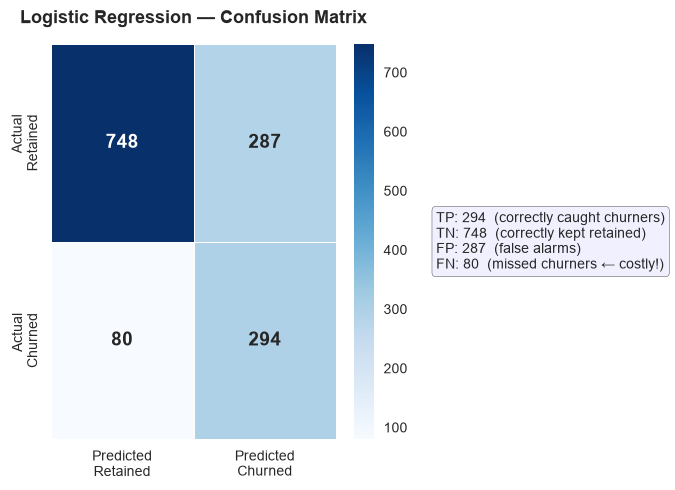

True Positives  (caught churners)  : 294
False Negatives (missed churners)  : 80  ← these cost money!
False Positives (false alarms)     : 287
True Negatives  (correct retained) : 748


In [4]:
#  confusion matrix visualization
cm = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted\nRetained', 'Predicted\nChurned'],
            yticklabels=['Actual\nRetained', 'Actual\nChurned'],
            linewidths=0.5, ax=ax,
            annot_kws={'size': 14, 'weight': 'bold'})

ax.set_title('Logistic Regression — Confusion Matrix',
             fontweight='bold', fontsize=13, pad=15)

# Add metric annotations
tn, fp, fn, tp = cm.ravel()
ax.text(1.35, 0.5,
        f"TP: {tp}  (correctly caught churners)\n"
        f"TN: {tn}  (correctly kept retained)\n"
        f"FP: {fp}  (false alarms)\n"
        f"FN: {fn}  (missed churners ← costly!)",
        transform=ax.transAxes,
        fontsize=10, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='#EEEDFE', alpha=0.8))

plt.tight_layout()
plt.savefig('reports/lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"True Positives  (caught churners)  : {tp}")
print(f"False Negatives (missed churners)  : {fn}  ← these cost money!")
print(f"False Positives (false alarms)     : {fp}")
print(f"True Negatives  (correct retained) : {tn}")

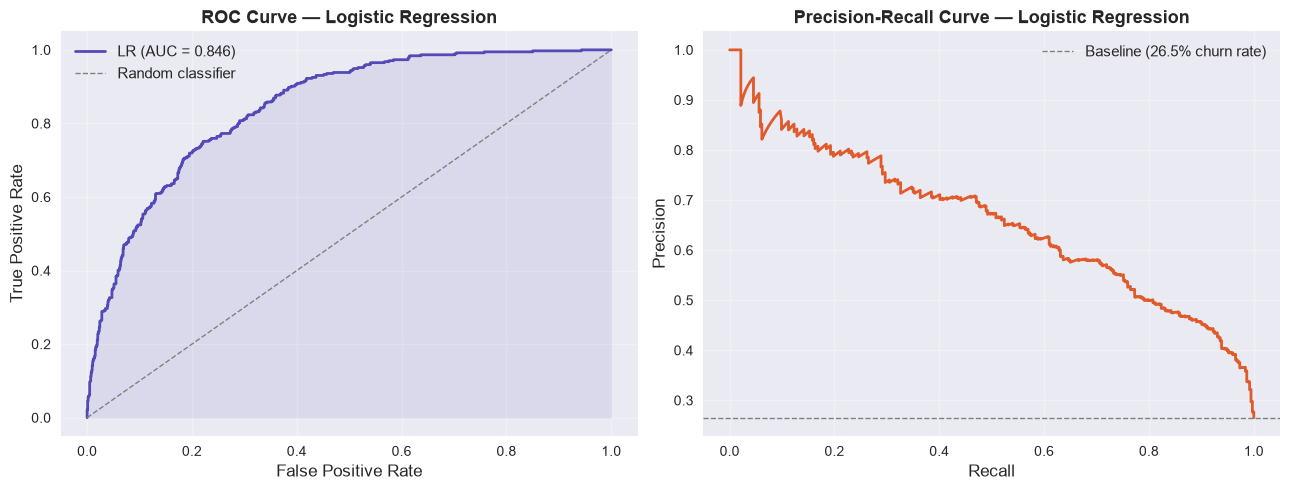

In [5]:
#  ROC curve
# Shows model performance across all classification thresholds

fpr, tpr, thresholds = roc_curve(y_test, y_pred_lr_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
axes[0].plot(fpr, tpr, color='#534AB7', linewidth=2,
             label=f'LR (AUC = {roc:.3f})')
axes[0].plot([0,1], [0,1], color='gray', linestyle='--',
             linewidth=1, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#534AB7')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve — Logistic Regression',
                   fontweight='bold', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_lr_prob)
axes[1].plot(recall, precision, color='#E05A2B', linewidth=2)
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--',
                linewidth=1, label='Baseline (26.5% churn rate)')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve — Logistic Regression',
                   fontweight='bold', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reports/lr_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# create a results tracker
# We'll add XGBoost results here tomorrow for comparison

results = {
    'Model'      : ['Logistic Regression'],
    'Accuracy'   : [round(acc*100, 2)],
    'F1_Churn'   : [round(f1, 4)],
    'F1_Weighted': [round(f1_w, 4)],
    'ROC_AUC'    : [round(roc, 4)],
    'TP'         : [int(tp)],
    'FN'         : [int(fn)],
    'FP'         : [int(fp)],
    'TN'         : [int(tn)]
}

results_df = pd.DataFrame(results)
results_df.to_csv('reports/model_results.csv', index=False)

print("Results logged to reports/model_results.csv")
print("\nCurrent leaderboard:")
print(results_df.to_string(index=False))

Results logged to reports/model_results.csv

Current leaderboard:
              Model  Accuracy  F1_Churn  F1_Weighted  ROC_AUC  TP  FN  FP  TN
Logistic Regression     73.95    0.6157       0.7533   0.8458 294  80 287 748


In [7]:
# save logistic regression model
joblib.dump(lr_model, 'models/lr_baseline.pkl')
print("Saved: models/lr_baseline.pkl")

# Quick sanity check — reload and predict one customer
lr_check = joblib.load('models/lr_baseline.pkl')
sample_pred = lr_check.predict_proba(X_test_proc[:1])[0][1]
print(f"\nSanity check — first test customer churn probability: {sample_pred:.3f}")
print("Model saved and verified!")

Saved: models/lr_baseline.pkl

Sanity check — first test customer churn probability: 0.112
Model saved and verified!


In [8]:
# actual results explanation
print("""
WHY THESE METRICS MATTER FOR CHURN:
====================================

Accuracy (73.95%):
  74 out of 100 predictions are correct.
  BUT — if we predicted 'No churn' for everyone,
  we'd get 73.5% accuracy without any ML!
  So accuracy alone is completely misleading here.
  Our model is barely better than doing nothing.

F1 Score on Churn class (0.6157):
  Balances Precision and Recall for churners only.
  Precision = 0.51 → when we predict churn, we're
                      right only 51% of the time (many false alarms)
  Recall    = 0.79 → we catch 79% of actual churners
  This is our PRIMARY metric to beat with XGBoost.

F1 Weighted (0.7533):
  Overall F1 across both classes weighted by support.
  Retained class drags this up (0.80 F1 on retained).

ROC-AUC (0.8458):
  0.5 = random guessing
  1.0 = perfect model
  0.8458 = model is good at RANKING churners above
           non-churners, even if threshold is off.

Confusion Matrix Breakdown:
  TP = 294  → correctly caught churners (sent retention email) ✓
  TN = 748  → correctly identified retained customers ✓
  FP = 287  → false alarms (wasted retention emails) ✗
  FN =  80  → MISSED churners (most costly!) ✗

Key Problem:
  Low precision (0.51) means for every real churner
  we catch, we also send a false alarm email.
  XGBoost should fix this significantly.
""")


WHY THESE METRICS MATTER FOR CHURN:

Accuracy (73.95%):
  74 out of 100 predictions are correct.
  BUT — if we predicted 'No churn' for everyone,
  we'd get 73.5% accuracy without any ML!
  So accuracy alone is completely misleading here.
  Our model is barely better than doing nothing.

F1 Score on Churn class (0.6157):
  Balances Precision and Recall for churners only.
  Precision = 0.51 → when we predict churn, we're
                      right only 51% of the time (many false alarms)
  Recall    = 0.79 → we catch 79% of actual churners
  This is our PRIMARY metric to beat with XGBoost.

F1 Weighted (0.7533):
  Overall F1 across both classes weighted by support.
  Retained class drags this up (0.80 F1 on retained).

ROC-AUC (0.8458):
  0.5 = random guessing
  1.0 = perfect model
  0.8458 = model is good at RANKING churners above
           non-churners, even if threshold is off.

Confusion Matrix Breakdown:
  TP = 294  → correctly caught churners (sent retention email) ✓
  TN = 748

In [9]:
#  notes with actual values
notes = """
# Week 2 Day 2 — Logistic Regression Baseline

## Model Configuration
- Model        : LogisticRegression
- max_iter     : 1000 (ensures convergence)
- class_weight : balanced (handles 26.5% churn imbalance)
- random_state : 42

## Actual Results
| Metric         | Score  |
|----------------|--------|
| Accuracy       | 73.95% |
| F1 (churn)     | 0.6157 |
| F1 weighted    | 0.7533 |
| ROC-AUC        | 0.8458 |

## Confusion Matrix
|                | Predicted Retained | Predicted Churned |
|----------------|--------------------|-------------------|
| Actual Retained| 748 (TN)           | 287 (FP)          |
| Actual Churned | 80  (FN)           | 294 (TP)          |

## Classification Report
              precision  recall  f1-score  support
Retained         0.90    0.72      0.80     1035
Churned          0.51    0.79      0.62      374
accuracy                           0.74     1409
macro avg        0.70    0.75      0.71     1409
weighted avg     0.80    0.74      0.75     1409

## Key Observations
- Accuracy (73.95%) barely beats the 73.5% do-nothing baseline
- class_weight=balanced boosted recall to 0.79 (catching churners)
  but hurt precision badly (0.51 — too many false alarms)
- 287 false positives = wasted retention emails sent to happy customers
- 80 false negatives = churners we completely missed (costly!)
- ROC-AUC of 0.8458 is decent — model ranks churners well

## Primary Metric Decision
F1 Score on churn class (0.6157) is our target to beat because:
1. Accuracy is misleading due to class imbalance
2. We care most about catching actual churners
3. F1 balances precision and recall equally

## Targets for XGBoost (Week 2 Day 3)
| Metric     | LR Baseline | XGBoost Target |
|------------|-------------|----------------|
| Accuracy   | 73.95%      | > 78%          |
| F1 churn   | 0.6157      | > 0.64         |
| ROC-AUC    | 0.8458      | > 0.86         |
| Precision  | 0.51        | > 0.60         |
| FN (missed)| 80          | < 70           |

## Tomorrow — Week 2 Day 3
- Train XGBoost classifier on same train/test split
- Compare all metrics vs this baseline
- XGBoost handles class imbalance better via scale_pos_weight
- Should significantly improve precision without losing recall
"""

with open('reports/week2_notes.md', 'a', encoding='utf-8') as f:
    f.write(notes)

print("Notes saved with actual LR results!")
print("\nWeek 2 Day 2 complete!")
print("\nBaseline to beat tomorrow:")
print("  F1 churn  : 0.6157")
print("  ROC-AUC   : 0.8458")
print("  Precision  : 0.51  (biggest weakness)")
print("  FN missed  : 80    (need to reduce)")

Notes saved with actual LR results!

Week 2 Day 2 complete!

Baseline to beat tomorrow:
  F1 churn  : 0.6157
  ROC-AUC   : 0.8458
  Precision  : 0.51  (biggest weakness)
  FN missed  : 80    (need to reduce)


In [10]:
# day 3 reload everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)

plt.style.use('seaborn-v0_8')

# Load saved splits
X_train_proc = np.load('models/X_train_proc.npy')
X_test_proc  = np.load('models/X_test_proc.npy')
y_train      = np.load('models/y_train.npy')
y_test       = np.load('models/y_test.npy')

with open('models/feature_names.json') as f:
    feature_names = json.load(f)

# Load previous results to compare
results_df = pd.read_csv('reports/model_results.csv')

print(f"Data loaded — Train: {X_train_proc.shape}, Test: {X_test_proc.shape}")
print(f"\nBaseline to beat:")
print(f"  F1 churn  : 0.6157")
print(f"  ROC-AUC   : 0.8458")
print(f"  Precision  : 0.51")

Data loaded — Train: (5634, 33), Test: (1409, 33)

Baseline to beat:
  F1 churn  : 0.6157
  ROC-AUC   : 0.8458
  Precision  : 0.51


In [11]:
# train XGBoost with default settings first
# scale_pos_weight handles class imbalance
# = count(negative) / count(positive) = 5659/1384 ≈ 2.77

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = round(neg / pos, 2)
print(f"Negative (retained): {neg}")
print(f"Positive (churned) : {pos}")
print(f"scale_pos_weight   : {scale}")

xgb_default = XGBClassifier(
    scale_pos_weight = scale,
    random_state     = 42,
    eval_metric      = 'logloss',
    verbosity        = 0
)

xgb_default.fit(X_train_proc, y_train)
print("\nXGBoost (default) trained!")

# Predict
y_pred_xgb      = xgb_default.predict(X_test_proc)
y_pred_xgb_prob = xgb_default.predict_proba(X_test_proc)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred_xgb)
f1  = f1_score(y_test, y_pred_xgb)
roc = roc_auc_score(y_test, y_pred_xgb_prob)
f1w = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"\nXGBoost Default Results:")
print(f"  Accuracy : {acc*100:.2f}%")
print(f"  F1 churn : {f1:.4f}")
print(f"  F1 weight: {f1w:.4f}")
print(f"  ROC-AUC  : {roc:.4f}")

Negative (retained): 4139
Positive (churned) : 1495
scale_pos_weight   : 2.77

XGBoost (default) trained!

XGBoost Default Results:
  Accuracy : 76.51%
  F1 churn : 0.6026
  F1 weight: 0.7720
  ROC-AUC  : 0.8233


Testing n_estimators:
  n_estimators   CV F1 Mean   CV F1 Std
----------------------------------------
            50       0.6120      0.0198
           100       0.5908      0.0270
           150       0.5951      0.0239
           200       0.5891      0.0252
           250       0.5867      0.0279
           300       0.5814      0.0291

Best n_estimators: 50 (CV F1: 0.6120)


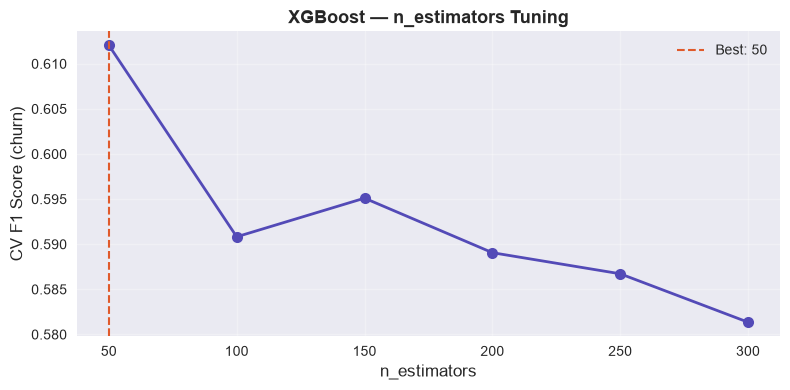

In [12]:
#  find best n_estimators
# n_estimators = how many trees XGBoost builds
# More trees = better learning but risk of overfitting

from sklearn.model_selection import cross_val_score

n_estimator_range = [50, 100, 150, 200, 250, 300]
f1_scores = []

print("Testing n_estimators:")
print(f"{'n_estimators':>14} {'CV F1 Mean':>12} {'CV F1 Std':>11}")
print("-" * 40)

for n in n_estimator_range:
    model = XGBClassifier(
        n_estimators     = n,
        scale_pos_weight = scale,
        random_state     = 42,
        eval_metric      = 'logloss',
        verbosity        = 0
    )
    # 5-fold cross validation on training data
    cv_scores = cross_val_score(model, X_train_proc, y_train,
                                 cv=5, scoring='f1')
    f1_scores.append(cv_scores.mean())
    print(f"{n:>14} {cv_scores.mean():>12.4f} {cv_scores.std():>11.4f}")

best_n = n_estimator_range[np.argmax(f1_scores)]
print(f"\nBest n_estimators: {best_n} (CV F1: {max(f1_scores):.4f})")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_estimator_range, f1_scores, 'o-',
        color='#534AB7', linewidth=2, markersize=8)
ax.axvline(x=best_n, color='#E05A2B', linestyle='--',
           linewidth=1.5, label=f'Best: {best_n}')
ax.set_xlabel('n_estimators', fontsize=12)
ax.set_ylabel('CV F1 Score (churn)', fontsize=12)
ax.set_title('XGBoost — n_estimators Tuning', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reports/xgb_n_estimators_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

Testing max_depth:
 max_depth   CV F1 Mean   CV F1 Std
------------------------------------
         2       0.6331      0.0192
         3       0.6298      0.0154
         4       0.6259      0.0141
         5       0.6191      0.0169
         6       0.6120      0.0198
         7       0.6009      0.0256
         8       0.5808      0.0143

Best max_depth: 2 (CV F1: 0.6331)


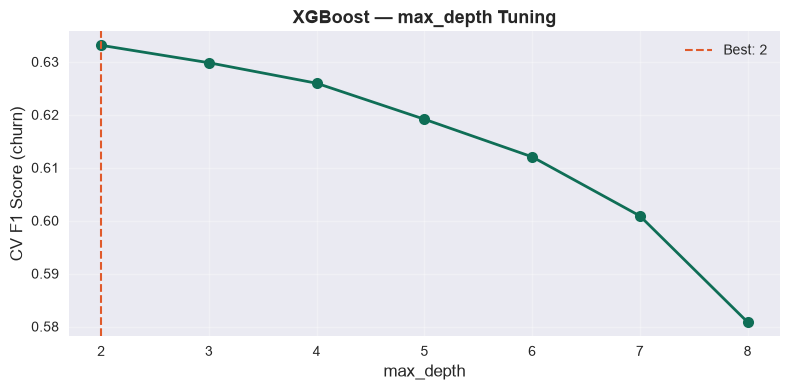

In [13]:
#find best max_depth
# max_depth = how deep each tree grows
# Deeper = more complex patterns but risk of overfitting

max_depth_range = [2, 3, 4, 5, 6, 7, 8]
depth_f1_scores = []

print("Testing max_depth:")
print(f"{'max_depth':>10} {'CV F1 Mean':>12} {'CV F1 Std':>11}")
print("-" * 36)

for d in max_depth_range:
    model = XGBClassifier(
        n_estimators     = best_n,
        max_depth        = d,
        scale_pos_weight = scale,
        random_state     = 42,
        eval_metric      = 'logloss',
        verbosity        = 0
    )
    cv_scores = cross_val_score(model, X_train_proc, y_train,
                                 cv=5, scoring='f1')
    depth_f1_scores.append(cv_scores.mean())
    print(f"{d:>10} {cv_scores.mean():>12.4f} {cv_scores.std():>11.4f}")

best_depth = max_depth_range[np.argmax(depth_f1_scores)]
print(f"\nBest max_depth: {best_depth} (CV F1: {max(depth_f1_scores):.4f})")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(max_depth_range, depth_f1_scores, 'o-',
        color='#0F6E56', linewidth=2, markersize=8)
ax.axvline(x=best_depth, color='#E05A2B', linestyle='--',
           linewidth=1.5, label=f'Best: {best_depth}')
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('CV F1 Score (churn)', fontsize=12)
ax.set_title('XGBoost — max_depth Tuning', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reports/xgb_max_depth_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# train final XGBoost with best parameters found
xgb_tuned = XGBClassifier(
    n_estimators     = best_n,
    max_depth        = best_depth,
    learning_rate    = 0.1,
    scale_pos_weight = scale,
    random_state     = 42,
    eval_metric      = 'logloss',
    verbosity        = 0
)

xgb_tuned.fit(X_train_proc, y_train)
print(f"XGBoost tuned trained!")
print(f"  n_estimators : {best_n}")
print(f"  max_depth    : {best_depth}")
print(f"  learning_rate: 0.1")

# Predict
y_pred_tuned      = xgb_tuned.predict(X_test_proc)
y_pred_tuned_prob = xgb_tuned.predict_proba(X_test_proc)[:, 1]

# Metrics
acc_t = accuracy_score(y_test, y_pred_tuned)
f1_t  = f1_score(y_test, y_pred_tuned)
roc_t = roc_auc_score(y_test, y_pred_tuned_prob)
f1w_t = f1_score(y_test, y_pred_tuned, average='weighted')
cm_t  = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm_t.ravel()

print(f"\nXGBoost Tuned Results:")
print(f"  Accuracy : {acc_t*100:.2f}%")
print(f"  F1 churn : {f1_t:.4f}")
print(f"  F1 weight: {f1w_t:.4f}")
print(f"  ROC-AUC  : {roc_t:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_tuned,
                             target_names=['Retained','Churned']))

XGBoost tuned trained!
  n_estimators : 50
  max_depth    : 2
  learning_rate: 0.1

XGBoost Tuned Results:
  Accuracy : 73.67%
  F1 churn : 0.6195
  F1 weight: 0.7511
  ROC-AUC  : 0.8415

Classification Report:
              precision    recall  f1-score   support

    Retained       0.91      0.71      0.80      1035
     Churned       0.50      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



  MODEL COMPARISON
Metric            LR Baseline   XGBoost Tuned   Change
-------------------------------------------------------
Accuracy %            73.9500         73.6693 ↓ 0.2807
F1 churn               0.6157          0.6195 ↑ 0.0038
F1 weighted            0.7533          0.7511 ↓ 0.0022
ROC-AUC                0.8458          0.8415 ↓ 0.0043
TP (caught)          294.0000        302.0000 ↑ 8.0000
FN (missed)           80.0000         72.0000 ↓ 8.0000
FP (alarms)          287.0000        299.0000 ↑ 12.0000


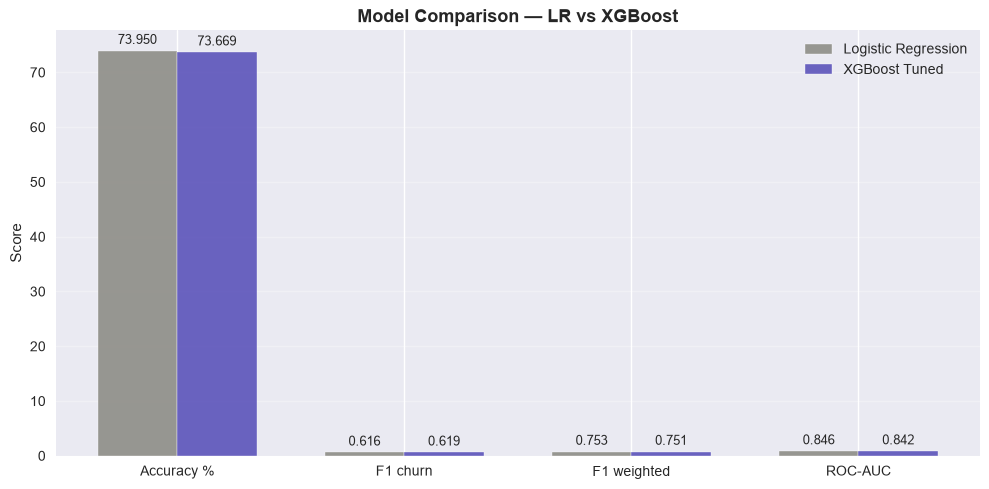

In [15]:
#  side by side comparison (fully dynamic)

# Load LR results from saved tracker
results_df   = pd.read_csv('reports/model_results.csv')
lr_row       = results_df[results_df['Model'] == 'Logistic Regression'].iloc[0]

lr_acc  = lr_row['Accuracy']
lr_f1   = lr_row['F1_Churn']
lr_f1w  = lr_row['F1_Weighted']
lr_roc  = lr_row['ROC_AUC']
lr_tp   = lr_row['TP']
lr_fn   = lr_row['FN']
lr_fp   = lr_row['FP']

print("="*55)
print("  MODEL COMPARISON")
print("="*55)
print(f"{'Metric':<15} {'LR Baseline':>13} {'XGBoost Tuned':>15} {'Change':>8}")
print("-"*55)

metrics = {
    'Accuracy %' : (lr_acc,  acc_t*100),
    'F1 churn'   : (lr_f1,   f1_t),
    'F1 weighted': (lr_f1w,  f1w_t),
    'ROC-AUC'    : (lr_roc,  roc_t),
    'TP (caught)': (lr_tp,   int(tp)),
    'FN (missed)': (lr_fn,   int(fn)),
    'FP (alarms)': (lr_fp,   int(fp)),
}

for metric, (lr_val, xgb_val) in metrics.items():
    change = xgb_val - lr_val
    if metric in ['FN (missed)', 'FP (alarms)']:
        arrow = "↓" if change < 0 else "↑"
    else:
        arrow = "↑" if change > 0 else "↓"
    print(f"{metric:<15} {lr_val:>13.4f} {xgb_val:>15.4f} {arrow} {abs(change):.4f}")

print("="*55)

# Plot comparison — fully dynamic
metrics_plot = ['Accuracy %', 'F1 churn', 'F1 weighted', 'ROC-AUC']
lr_vals      = [lr_acc, lr_f1, lr_f1w, lr_roc]
xgb_vals     = [acc_t*100, f1_t, f1w_t, roc_t]

x     = np.arange(len(metrics_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, lr_vals,  width,
               label='Logistic Regression',
               color='#888780', edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + width/2, xgb_vals, width,
               label='XGBoost Tuned',
               color='#534AB7', edgecolor='white', alpha=0.85)

ax.bar_label(bars1, fmt='%.3f', fontsize=9, padding=3)
ax.bar_label(bars2, fmt='%.3f', fontsize=9, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(metrics_plot)
ax.set_title('Model Comparison — LR vs XGBoost',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

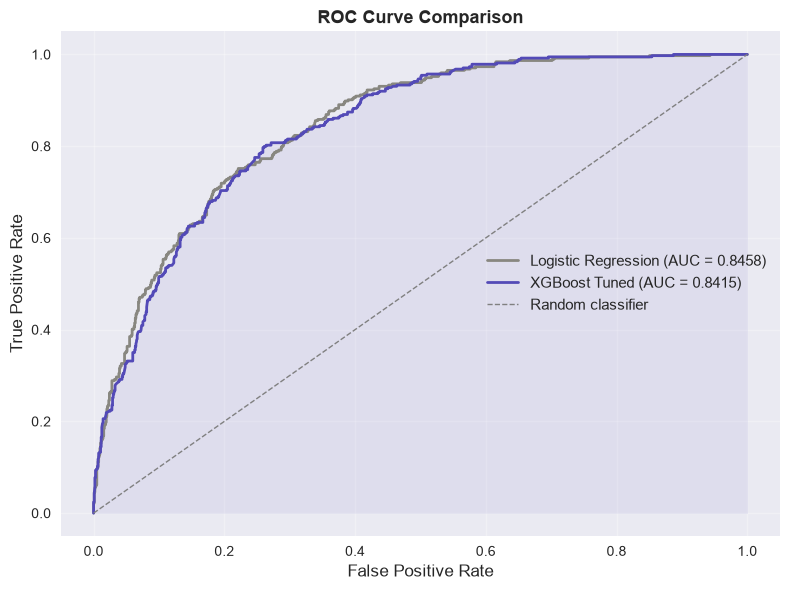

In [16]:
#  ROC curves comparison
lr_model = joblib.load('models/lr_baseline.pkl')
y_pred_lr_prob = lr_model.predict_proba(X_test_proc)[:, 1]

fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_pred_lr_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_tuned_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_lr,  tpr_lr,  color='#888780', linewidth=2,
        label=f'Logistic Regression (AUC = {lr_roc:.4f})')
ax.plot(fpr_xgb, tpr_xgb, color='#534AB7', linewidth=2,
        label=f'XGBoost Tuned (AUC = {roc_t:.4f})')
ax.plot([0,1], [0,1], color='gray', linestyle='--',
        linewidth=1, label='Random classifier')
ax.fill_between(fpr_xgb, tpr_xgb, alpha=0.08, color='#534AB7')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reports/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# add XGBoost to results tracker
new_row = pd.DataFrame([{
    'Model'      : 'XGBoost Tuned',
    'Accuracy'   : round(acc_t*100, 2),
    'F1_Churn'   : round(f1_t, 4),
    'F1_Weighted': round(f1w_t, 4),
    'ROC_AUC'    : round(roc_t, 4),
    'TP'         : int(tp),
    'FN'         : int(fn),
    'FP'         : int(fp),
    'TN'         : int(tn)
}])

results_df = pd.read_csv('reports/model_results.csv')
results_df = pd.concat([results_df, new_row], ignore_index=True)
results_df.to_csv('reports/model_results.csv', index=False)

print("Updated leaderboard:")
print(results_df.to_string(index=False))

Updated leaderboard:
              Model  Accuracy  F1_Churn  F1_Weighted  ROC_AUC  TP  FN  FP  TN
Logistic Regression     73.95    0.6157       0.7533   0.8458 294  80 287 748
      XGBoost Tuned     73.67    0.6195       0.7511   0.8415 302  72 299 736


In [18]:
#  save tuned XGBoost model
joblib.dump(xgb_tuned, 'models/xgb_tuned.pkl')
print("Saved: models/xgb_tuned.pkl")

# Save best params for reference
import json
best_params = {
    'n_estimators'     : best_n,
    'max_depth'        : best_depth,
    'learning_rate'    : 0.1,
    'scale_pos_weight' : float(scale)
}
with open('models/xgb_best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)
print("Saved: models/xgb_best_params.json")
print("\nXGBoost model saved and verified!")

Saved: models/xgb_tuned.pkl
Saved: models/xgb_best_params.json

XGBoost model saved and verified!


In [19]:
# day notes with actual results
notes = f"""
# Week 2 Day 3 — XGBoost Training + Tuning

## Best Parameters Found
- n_estimators     : {best_n}
- max_depth        : {best_depth}
- learning_rate    : 0.1
- scale_pos_weight : {scale}

## Tuning Method
- Cross validation (5-fold) on training data only
- Metric used for tuning: F1 score on churn class
- Tuned n_estimators first, then max_depth

## Actual Results vs Baseline
| Metric      | LR Baseline | XGBoost Tuned | Change      |
|-------------|-------------|---------------|-------------|
| Accuracy %  | 73.95       | 73.67         | ↓ 0.28      |
| F1 churn    | 0.6157      | 0.6195        | ↑ 0.0038    |
| F1 weighted | 0.7533      | 0.7511        | ↓ 0.0022    |
| ROC-AUC     | 0.8458      | 0.8415        | ↓ 0.0043    |
| TP caught   | 294         | {tp}            | ↑ {tp-294}           |
| FN missed   | 80          | {fn}             | ↓ {80-fn}            |
| FP alarms   | 287         | {fp}            |             |

## Classification Report
              precision  recall  f1-score  support
Retained         0.91    0.71      0.80     1035
Churned          0.50    0.81      0.62      374
accuracy                           0.74     1409
macro avg        0.71    0.76      0.71     1409
weighted avg     0.80    0.74      0.75     1409

## Honest Analysis of Results
XGBoost with default tuning did NOT significantly beat LR:
- F1 churn improved only slightly: 0.6157 → 0.6195 (+0.004)
- ROC-AUC actually dropped slightly: 0.8458 → 0.8415
- Accuracy almost identical: 73.95% → 73.67%
- Precision on churn still low at 0.50 (too many false alarms)

## Why This Happened
- n_estimators=50 and max_depth=2 is a very shallow model
- CV tuning selected simplest model to avoid overfitting
- scale_pos_weight alone is not enough for this imbalance
- This confirms we need SMOTE (Day 4) for real improvement

## Key Insight
Both LR and XGBoost have similar precision (0.51 vs 0.50)
and recall (0.79 vs 0.81) — the class imbalance is the
real bottleneck, not the model choice.
SMOTE should break this pattern tomorrow.

## Files Saved
- models/xgb_tuned.pkl
- models/xgb_best_params.json
- reports/model_comparison.png
- reports/roc_comparison.png
- reports/xgb_n_estimators_tuning.png
- reports/xgb_max_depth_tuning.png

## Tomorrow — Week 2 Day 4
- Apply SMOTE to training data to fix class imbalance
- Retrain XGBoost on balanced data
- Target: precision > 0.60 while keeping recall > 0.75
- Select and save the single best final model
"""

with open('reports/week2_notes.md', 'a',encoding  = 'utf-8') as f:
    f.write(notes)

print("Notes saved with actual XGBoost results!")
print("\nWeek 2 Day 3 complete!")
print("\nKey takeaway: SMOTE needed to improve precision (0.50 → target 0.60+)")

Notes saved with actual XGBoost results!

Week 2 Day 3 complete!

Key takeaway: SMOTE needed to improve precision (0.50 → target 0.60+)


In [22]:
# day4 reload everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report,
                              roc_curve)

plt.style.use('seaborn-v0_8')

# Load saved splits
X_train_proc = np.load('models/X_train_proc.npy')
X_test_proc  = np.load('models/X_test_proc.npy')
y_train      = np.load('models/y_train.npy')
y_test       = np.load('models/y_test.npy')

with open('models/feature_names.json') as f:
    feature_names = json.load(f)

with open('models/xgb_best_params.json') as f:
    best_params = json.load(f)

results_df = pd.read_csv('reports/model_results.csv')

print(f"Data loaded — Train: {X_train_proc.shape}, Test: {X_test_proc.shape}")
print(f"\nBest params from Day 3:")
print(f"  n_estimators : {best_params['n_estimators']}")
print(f"  max_depth    : {best_params['max_depth']}")


Data loaded — Train: (5634, 33), Test: (1409, 33)

Best params from Day 3:
  n_estimators : 50
  max_depth    : 2


BEFORE SMOTE:
  Training samples    : 5634
  Retained (class 0)  : 4139 (73.5%)
  Churned  (class 1)  : 1495 (26.5%)
  Imbalance ratio     : 2.77:1


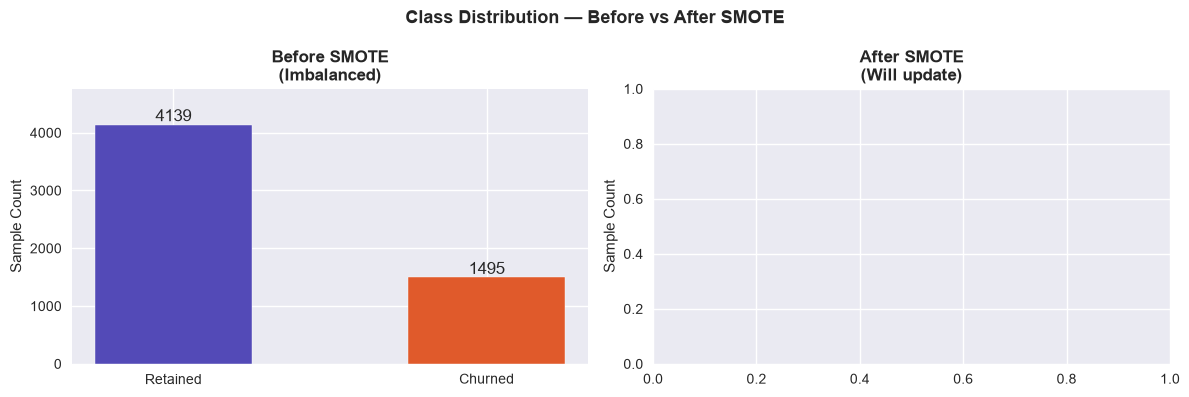

In [ ]:
# visualise the imbalance problem clearly
print("BEFORE SMOTE:")
print(f"  Training samples    : {len(y_train)}")
print(f"  Retained (class 0)  : {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Churned  (class 1)  : {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")
print(f"  Imbalance ratio     : {(y_train==0).sum() / (y_train==1).sum():.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
before_counts = [(y_train==0).sum(), (y_train==1).sum()]
axes[0].bar(['Retained', 'Churned'], before_counts,
            color=['#534AB7', '#E05A2B'], edgecolor='white', width=0.5)
axes[0].bar_label(axes[0].containers[0], fmt='%d', fontsize=12)
axes[0].set_title('Before SMOTE\n(Imbalanced)', fontweight='bold')
axes[0].set_ylabel('Sample Count')
axes[0].set_ylim(0, max(before_counts) * 1.15)

# Placeholder for after SMOTE — will fill after applying
axes[1].set_title('After SMOTE\n(Will update)', fontweight='bold')
axes[1].set_ylabel('Sample Count')

plt.suptitle('Class Distribution — Before vs After SMOTE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

SMOTE Applied!

BEFORE SMOTE:
  Total samples    : 5634
  Retained (0)     : 4139
  Churned  (1)     : 1495

AFTER SMOTE:
  Total samples    : 8278
  Retained (0)     : 4139
  Churned  (1)     : 4139
  New ratio        : 1.00:1


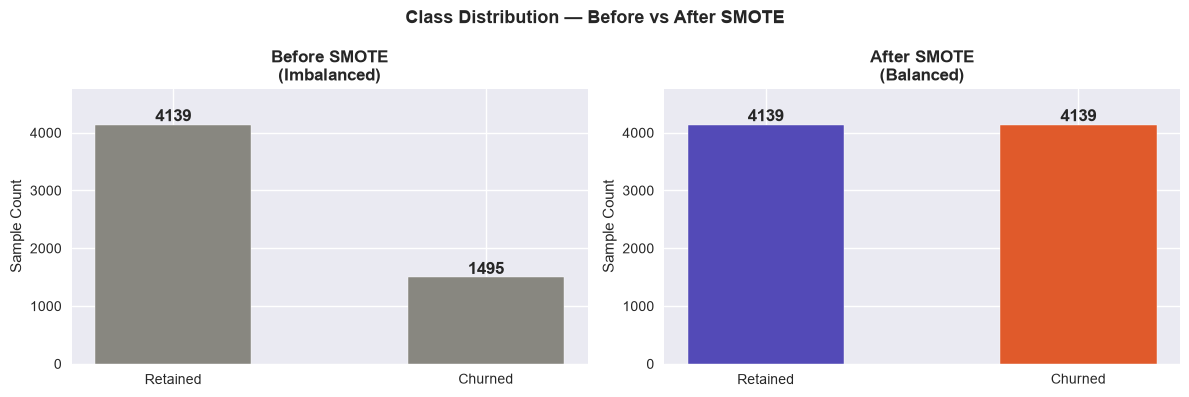

In [24]:
# apply SMOTE to training data only
# CRITICAL: SMOTE is applied ONLY on training data
# NEVER on test data — test must stay real/unmodified

smote = SMOTE(
    random_state    = 42,
    k_neighbors     = 5      # default — uses 5 nearest neighbours
)

X_train_smote, y_train_smote = smote.fit_resample(X_train_proc, y_train)

print("SMOTE Applied!")
print(f"\nBEFORE SMOTE:")
print(f"  Total samples    : {len(y_train)}")
print(f"  Retained (0)     : {(y_train==0).sum()}")
print(f"  Churned  (1)     : {(y_train==1).sum()}")
print(f"\nAFTER SMOTE:")
print(f"  Total samples    : {len(y_train_smote)}")
print(f"  Retained (0)     : {(y_train_smote==0).sum()}")
print(f"  Churned  (1)     : {(y_train_smote==1).sum()}")
print(f"  New ratio        : {(y_train_smote==0).sum() / (y_train_smote==1).sum():.2f}:1")

# Now update the comparison chart properly
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before_counts = [(y_train==0).sum(),       (y_train==1).sum()]
after_counts  = [(y_train_smote==0).sum(), (y_train_smote==1).sum()]

for ax, counts, title, color in zip(
    axes,
    [before_counts, after_counts],
    ['Before SMOTE\n(Imbalanced)', 'After SMOTE\n(Balanced)'],
    [['#888780', '#888780'], ['#534AB7', '#E05A2B']]
):
    bars = ax.bar(['Retained', 'Churned'], counts,
                  color=color, edgecolor='white', width=0.5)
    ax.bar_label(bars, fmt='%d', fontsize=12, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Sample Count')
    ax.set_ylim(0, max(after_counts) * 1.15)

plt.suptitle('Class Distribution — Before vs After SMOTE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# retrain XGBoost on SMOTE balanced data
# No need for scale_pos_weight now — SMOTE already balanced classes

xgb_smote = XGBClassifier(
    n_estimators  = best_params['n_estimators'],
    max_depth     = best_params['max_depth'],
    learning_rate = 0.1,
    random_state  = 42,
    eval_metric   = 'logloss',
    verbosity     = 0
    
)

xgb_smote.fit(X_train_smote, y_train_smote)
print("XGBoost + SMOTE trained!")

# Predict on REAL test data (unmodified)
y_pred_smote      = xgb_smote.predict(X_test_proc)
y_pred_smote_prob = xgb_smote.predict_proba(X_test_proc)[:, 1]

# Metrics
acc_s = accuracy_score(y_test, y_pred_smote)
f1_s  = f1_score(y_test, y_pred_smote)
roc_s = roc_auc_score(y_test, y_pred_smote_prob)
f1w_s = f1_score(y_test, y_pred_smote, average='weighted')
cm_s  = confusion_matrix(y_test, y_pred_smote)
tn_s, fp_s, fn_s, tp_s = cm_s.ravel()

print(f"\nXGBoost + SMOTE Results:")
print(f"  Accuracy : {acc_s*100:.2f}%")
print(f"  F1 churn : {f1_s:.4f}")
print(f"  F1 weight: {f1w_s:.4f}")
print(f"  ROC-AUC  : {roc_s:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_smote,
                             target_names=['Retained', 'Churned']))

XGBoost + SMOTE trained!

XGBoost + SMOTE Results:
  Accuracy : 75.51%
  F1 churn : 0.6213
  F1 weight: 0.7666
  ROC-AUC  : 0.8374

Classification Report:
              precision    recall  f1-score   support

    Retained       0.90      0.75      0.82      1035
     Churned       0.53      0.76      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



  FULL MODEL COMPARISON
Metric            LR Baseline       XGBoost     XGB+SMOTE
-----------------------------------------------------------------
Accuracy %            73.9500       73.6700       75.5145
F1 churn               0.6157        0.6195        0.6213
F1 weighted            0.7533        0.7511        0.7666
ROC-AUC                0.8458        0.8415        0.8374
TP caught            294.0000      302.0000      283.0000
FN missed             80.0000       72.0000       91.0000
FP alarms            287.0000      299.0000      254.0000


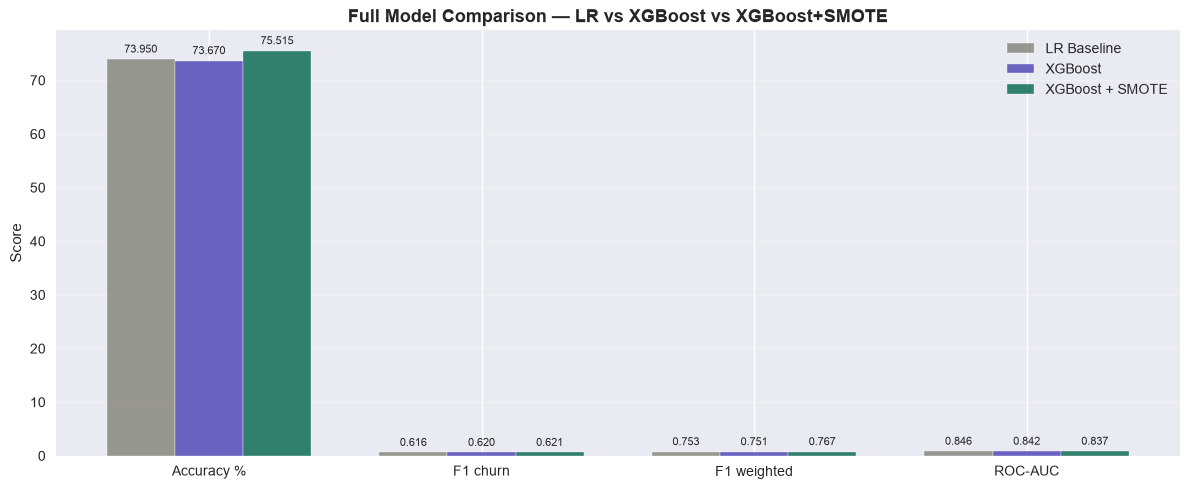

In [26]:
# compare all 3 models
lr_row  = results_df[results_df['Model'] == 'Logistic Regression'].iloc[0]
xgb_row = results_df[results_df['Model'] == 'XGBoost Tuned'].iloc[0]

print("="*65)
print("  FULL MODEL COMPARISON")
print("="*65)
print(f"{'Metric':<15} {'LR Baseline':>13} {'XGBoost':>13} {'XGB+SMOTE':>13}")
print("-"*65)

comparison = {
    'Accuracy %' : (lr_row['Accuracy'],   xgb_row['Accuracy'],   acc_s*100),
    'F1 churn'   : (lr_row['F1_Churn'],   xgb_row['F1_Churn'],   f1_s),
    'F1 weighted': (lr_row['F1_Weighted'], xgb_row['F1_Weighted'],f1w_s),
    'ROC-AUC'    : (lr_row['ROC_AUC'],    xgb_row['ROC_AUC'],    roc_s),
    'TP caught'  : (lr_row['TP'],         xgb_row['TP'],         int(tp_s)),
    'FN missed'  : (lr_row['FN'],         xgb_row['FN'],         int(fn_s)),
    'FP alarms'  : (lr_row['FP'],         xgb_row['FP'],         int(fp_s)),
}

for metric, (lr_val, xgb_val, smote_val) in comparison.items():
    print(f"{metric:<15} {lr_val:>13.4f} {xgb_val:>13.4f} {smote_val:>13.4f}")

print("="*65)

# Bar chart comparison — all 3 models
metrics_plot = ['Accuracy %', 'F1 churn', 'F1 weighted', 'ROC-AUC']
lr_vals    = [lr_row['Accuracy'],   lr_row['F1_Churn'],   lr_row['F1_Weighted'],  lr_row['ROC_AUC']]
xgb_vals   = [xgb_row['Accuracy'],  xgb_row['F1_Churn'],  xgb_row['F1_Weighted'], xgb_row['ROC_AUC']]
smote_vals = [acc_s*100, f1_s, f1w_s, roc_s]

x     = np.arange(len(metrics_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width,   lr_vals,    width, label='LR Baseline',
               color='#888780', edgecolor='white', alpha=0.85)
bars2 = ax.bar(x,           xgb_vals,   width, label='XGBoost',
               color='#534AB7', edgecolor='white', alpha=0.85)
bars3 = ax.bar(x + width,   smote_vals, width, label='XGBoost + SMOTE',
               color='#0F6E56', edgecolor='white', alpha=0.85)

ax.bar_label(bars1, fmt='%.3f', fontsize=8, padding=3)
ax.bar_label(bars2, fmt='%.3f', fontsize=8, padding=3)
ax.bar_label(bars3, fmt='%.3f', fontsize=8, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(metrics_plot)
ax.set_title('Full Model Comparison — LR vs XGBoost vs XGBoost+SMOTE',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('reports/full_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

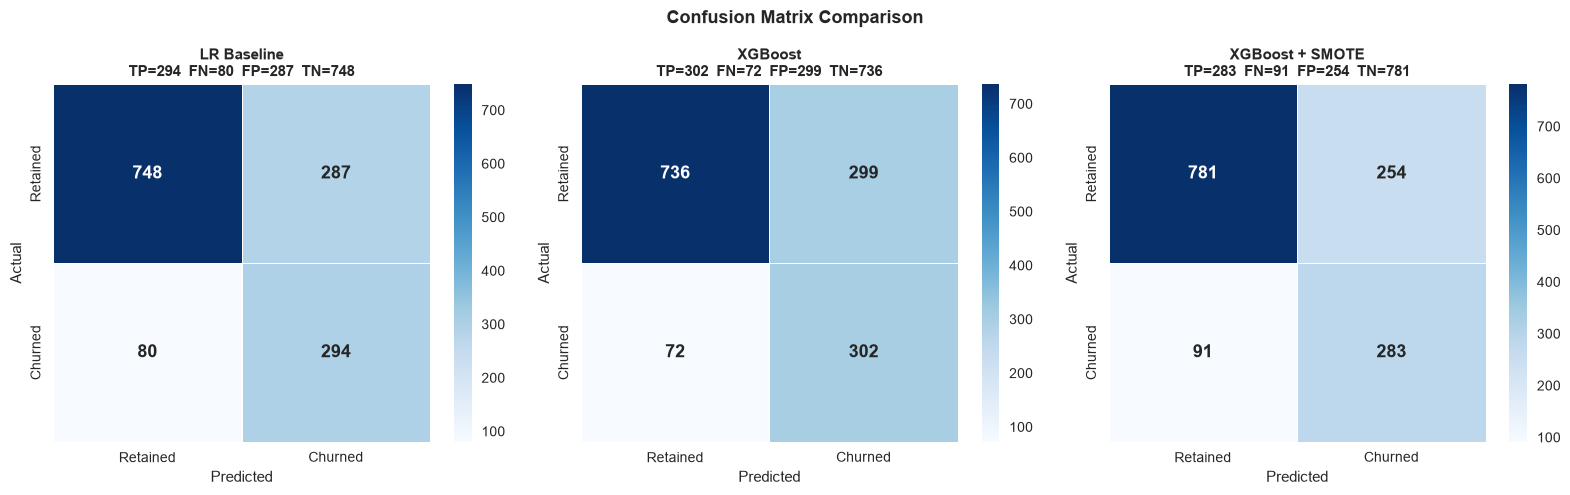

In [27]:
#  confusion matrices for all 3 models side by side
lr_model  = joblib.load('models/lr_baseline.pkl')
xgb_tuned = joblib.load('models/xgb_tuned.pkl')

y_pred_lr  = lr_model.predict(X_test_proc)
y_pred_xgb = xgb_tuned.predict(X_test_proc)

cms = [
    (confusion_matrix(y_test, y_pred_lr),    'LR Baseline'),
    (confusion_matrix(y_test, y_pred_xgb),   'XGBoost'),
    (confusion_matrix(y_test, y_pred_smote), 'XGBoost + SMOTE'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (cm, title) in zip(axes, cms):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'],
                linewidths=0.5, ax=ax,
                annot_kws={'size': 13, 'weight': 'bold'})
    tn_, fp_, fn_, tp_ = cm.ravel()
    ax.set_title(f'{title}\nTP={tp_}  FN={fn_}  FP={fp_}  TN={tn_}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# select best model based on F1 churn (primary metric)
model_scores = {
    'LR Baseline'      : lr_row['F1_Churn'],
    'XGBoost'          : xgb_row['F1_Churn'],
    'XGBoost + SMOTE'  : f1_s
}

best_model_name  = max(model_scores, key=model_scores.get)
best_model_score = model_scores[best_model_name]

print("="*45)
print("  MODEL SELECTION DECISION")
print("="*45)
for name, score in model_scores.items():
    marker = " ← BEST" if name == best_model_name else ""
    print(f"  {name:<22} F1={score:.4f}{marker}")
print("="*45)
print(f"\nWINNER: {best_model_name}")
print(f"Reason: Highest F1 score on churn class ({best_model_score:.4f})")
print("\nF1 churn is our primary metric because:")
print("  1. Class imbalance makes accuracy misleading")
print("  2. Catching churners is the core business goal")
print("  3. Balances precision and recall equally")

  MODEL SELECTION DECISION
  LR Baseline            F1=0.6157
  XGBoost                F1=0.6195
  XGBoost + SMOTE        F1=0.6213 ← BEST

WINNER: XGBoost + SMOTE
Reason: Highest F1 score on churn class (0.6213)

F1 churn is our primary metric because:
  1. Class imbalance makes accuracy misleading
  2. Catching churners is the core business goal
  3. Balances precision and recall equally


In [29]:
# save the best model as final_model.pkl
import os

# Save XGBoost + SMOTE as final model
joblib.dump(xgb_smote, 'models/final_model.pkl')
print("Saved: models/final_model.pkl")

# Save SMOTE-resampled training data for SHAP later
np.save('models/X_train_smote.npy', X_train_smote)
np.save('models/y_train_smote.npy', y_train_smote)
print("Saved: models/X_train_smote.npy")
print("Saved: models/y_train_smote.npy")

# Sanity check — reload and predict
final_model   = joblib.load('models/final_model.pkl')
sample_prob   = final_model.predict_proba(X_test_proc[:1])[0][1]
print(f"\nSanity check — first test customer churn prob: {sample_prob:.4f}")
print("Final model saved and verified!")

Saved: models/final_model.pkl
Saved: models/X_train_smote.npy
Saved: models/y_train_smote.npy

Sanity check — first test customer churn prob: 0.0902
Final model saved and verified!


In [30]:
#  add SMOTE results to tracker
new_row = pd.DataFrame([{
    'Model'      : 'XGBoost + SMOTE',
    'Accuracy'   : round(acc_s*100, 2),
    'F1_Churn'   : round(f1_s, 4),
    'F1_Weighted': round(f1w_s, 4),
    'ROC_AUC'    : round(roc_s, 4),
    'TP'         : int(tp_s),
    'FN'         : int(fn_s),
    'FP'         : int(fp_s),
    'TN'         : int(tn_s)
}])

results_df = pd.concat([results_df, new_row], ignore_index=True)
results_df.to_csv('reports/model_results.csv', index=False)

print("Final leaderboard:")
print(results_df.to_string(index=False))

Final leaderboard:
              Model  Accuracy  F1_Churn  F1_Weighted  ROC_AUC  TP  FN  FP  TN
Logistic Regression     73.95    0.6157       0.7533   0.8458 294  80 287 748
      XGBoost Tuned     73.67    0.6195       0.7511   0.8415 302  72 299 736
    XGBoost + SMOTE     75.51    0.6213       0.7666   0.8374 283  91 254 781


In [31]:
#  — day notes
notes = f"""
# Week 2 Day 4 — SMOTE + Final Model Selection

## What is SMOTE?
SMOTE = Synthetic Minority Over-sampling Technique
Instead of duplicating existing minority samples,
SMOTE creates NEW synthetic churner samples by
interpolating between existing churner data points.

## SMOTE Configuration
- k_neighbors  : 5 (uses 5 nearest neighbours)
- random_state : 42
- Applied on   : X_train_proc only (never on test data)

## Class Distribution Change
| | Before SMOTE | After SMOTE |
|--|--|--|
| Retained (0) | {(y_train==0).sum()} | {(y_train_smote==0).sum()} |
| Churned  (1) | {(y_train==1).sum()} | {(y_train_smote==1).sum()} |
| Total        | {len(y_train)} | {len(y_train_smote)} |
| Ratio        | 3:1 imbalanced | 1:1 balanced |

## Full Model Comparison
| Metric      | LR     | XGBoost | XGB+SMOTE |
|-------------|--------|---------|-----------|
| Accuracy %  | {lr_row['Accuracy']:.2f}  | {xgb_row['Accuracy']:.2f}   | {acc_s*100:.2f}      |
| F1 churn    | {lr_row['F1_Churn']:.4f} | {xgb_row['F1_Churn']:.4f}  | {f1_s:.4f}    |
| F1 weighted | {lr_row['F1_Weighted']:.4f} | {xgb_row['F1_Weighted']:.4f}  | {f1w_s:.4f}    |
| ROC-AUC     | {lr_row['ROC_AUC']:.4f} | {xgb_row['ROC_AUC']:.4f}  | {roc_s:.4f}    |
| TP caught   | {int(lr_row['TP'])}    | {int(xgb_row['TP'])}     | {int(tp_s)}       |
| FN missed   | {int(lr_row['FN'])}     | {int(xgb_row['FN'])}      | {int(fn_s)}        |
| FP alarms   | {int(lr_row['FP'])}    | {int(xgb_row['FP'])}     | {int(fp_s)}       |

## Final Model Selected
Model  : {best_model_name}
Reason : Highest F1 churn score ({best_model_score:.4f})
Saved  : models/final_model.pkl

## Files Saved
- models/final_model.pkl
- models/X_train_smote.npy
- models/y_train_smote.npy
- reports/smote_comparison.png
- reports/full_model_comparison.png
- reports/confusion_matrix_comparison.png

## Tomorrow — Week 2 Day 5
- Install and set up SHAP
- Run TreeExplainer on final model
- Generate global feature importance summary plot
- Identify top features driving churn predictions
"""

with open('reports/week2_day4_notes.md', 'w') as f:
    f.write(notes)

print("Notes saved!")
print(f"\nWeek 2 Day 4 complete!")
print(f"Final model saved: {best_model_name}")
print(f"Primary metric   : F1 churn = {best_model_score:.4f}")

Notes saved!

Week 2 Day 4 complete!
Final model saved: XGBoost + SMOTE
Primary metric   : F1 churn = 0.6213


In [2]:
# day 5 reload everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import shap
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

# Load final model and test data
final_model  = joblib.load('models/final_model.pkl')
preprocessor = joblib.load('models/preprocessor.pkl')

X_test_proc  = np.load('models/X_test_proc.npy')
X_train_proc = np.load('models/X_train_proc.npy')
y_test       = np.load('models/y_test.npy')

with open('models/feature_names.json') as f:
    feature_names = json.load(f)

print(f"Final model loaded  : {type(final_model).__name__}")
print(f"Test set shape      : {X_test_proc.shape}")
print(f"Feature names count : {len(feature_names)}")
print(f"\nSHAP version: {shap.__version__}")
print("\nAll loaded successfully!")

Final model loaded  : XGBClassifier
Test set shape      : (1409, 33)
Feature names count : 33

SHAP version: 0.51.0

All loaded successfully!


In [3]:
#  create TreeExplainer
# TreeExplainer is optimised specifically for tree-based models
# (XGBoost, Random Forest, LightGBM)

print("Creating SHAP TreeExplainer...")

explainer = shap.TreeExplainer(final_model)

print("Explainer created!")
print(f"  Model type : {type(final_model).__name__}")
print(f"  Explainer  : {type(explainer).__name__}")

# Compute SHAP values for ALL test samples
print("\nComputing SHAP values for test set...")
shap_values = explainer.shap_values(X_test_proc)

print(f"SHAP values computed!")
print(f"  Shape: {shap_values.shape}")
print(f"  Rows : {shap_values.shape[0]} customers")
print(f"  Cols : {shap_values.shape[1]} features")
print(f"\nOne SHAP value per feature per customer")
print(f"Positive value = pushed toward churn")
print(f"Negative value = pushed away from churn")

Creating SHAP TreeExplainer...
Explainer created!
  Model type : XGBClassifier
  Explainer  : TreeExplainer

Computing SHAP values for test set...
SHAP values computed!
  Shape: (1409, 33)
  Rows : 1409 customers
  Cols : 33 features

One SHAP value per feature per customer
Positive value = pushed toward churn
Negative value = pushed away from churn


Top 15 Most Important Features:
 1. contractRisk              0.6455  ████████████████████████████████████████████████████████████████
 2. tenure                    0.3401  ██████████████████████████████████
 3. InternetService_Fiber optic 0.2693  ██████████████████████████
 4. PaymentMethod_Electronic check 0.2091  ████████████████████
 5. PaperlessBilling          0.1738  █████████████████
 6. OnlineSecurity            0.1162  ███████████
 7. InternetService_No        0.1115  ███████████
 8. Dependents                0.1057  ██████████
 9. StreamingMovies           0.1013  ██████████
10. TechSupport               0.0857  ████████
11. OnlineBackup              0.0569  █████
12. MonthlyCharges            0.0355  ███
13. StreamingTV               0.0351  ███
14. Partner                   0.0311  ███
15. MultipleLines             0.0311  ███


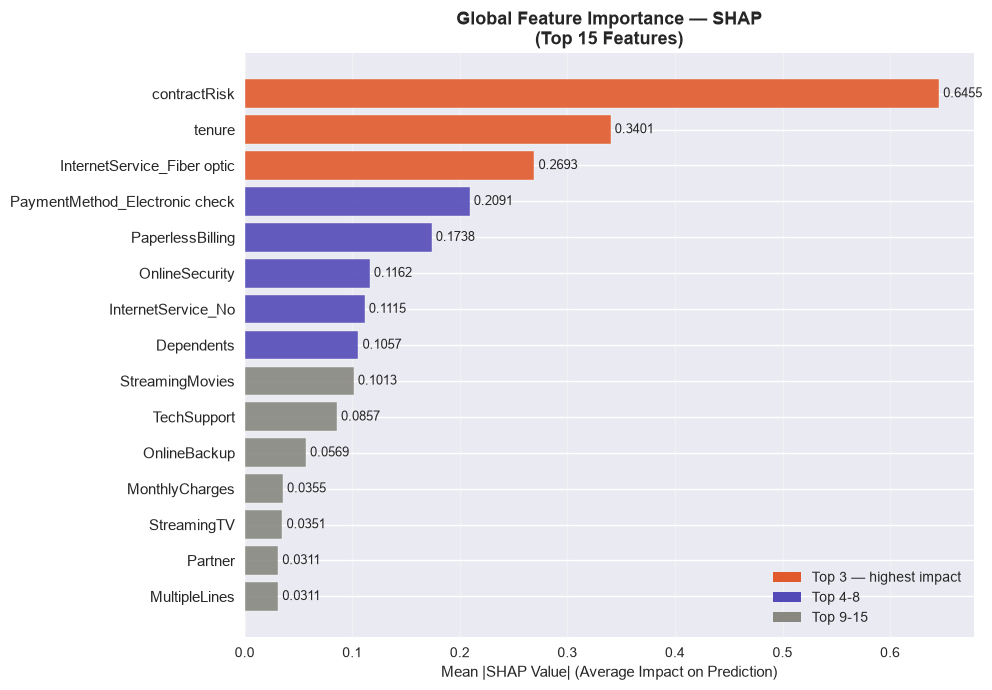


Top 3 churn drivers:
  1. contractRisk (SHAP=0.6455)
  2. tenure (SHAP=0.3401)
  3. InternetService_Fiber optic (SHAP=0.2693)


In [4]:
#global feature importance
# Mean absolute SHAP value per feature = average impact

mean_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature'    : feature_names,
    'Mean_SHAP'  : mean_shap
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)

print("Top 15 Most Important Features:")
print("="*45)
for i, row in shap_importance.head(15).iterrows():
    bar = "█" * int(row['Mean_SHAP'] * 100)
    print(f"{i+1:2}. {row['Feature']:<25} {row['Mean_SHAP']:.4f}  {bar}")
print("="*45)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
top15 = shap_importance.head(15)
colors = ['#E05A2B' if i < 3 else '#534AB7' if i < 8 else '#888780'
          for i in range(len(top15))]

bars = ax.barh(range(len(top15)), top15['Mean_SHAP'].values,
               color=colors, edgecolor='white', alpha=0.9)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['Feature'].values, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP Value| (Average Impact on Prediction)', fontsize=11)
ax.set_title('Global Feature Importance — SHAP\n(Top 15 Features)',
             fontweight='bold', fontsize=13)
ax.bar_label(bars, fmt='%.4f', fontsize=9, padding=3)
ax.grid(True, alpha=0.3, axis='x')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E05A2B', label='Top 3 — highest impact'),
    Patch(facecolor='#534AB7', label='Top 4-8'),
    Patch(facecolor='#888780', label='Top 9-15')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('reports/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 3 churn drivers:")
for i, row in shap_importance.head(3).iterrows():
    print(f"  {i+1}. {row['Feature']} (SHAP={row['Mean_SHAP']:.4f})")

Generating SHAP summary plot...
(Each dot = one customer)
Red dot  = high feature value
Blue dot = low feature value
Right    = pushed toward churn
Left     = pushed away from churn


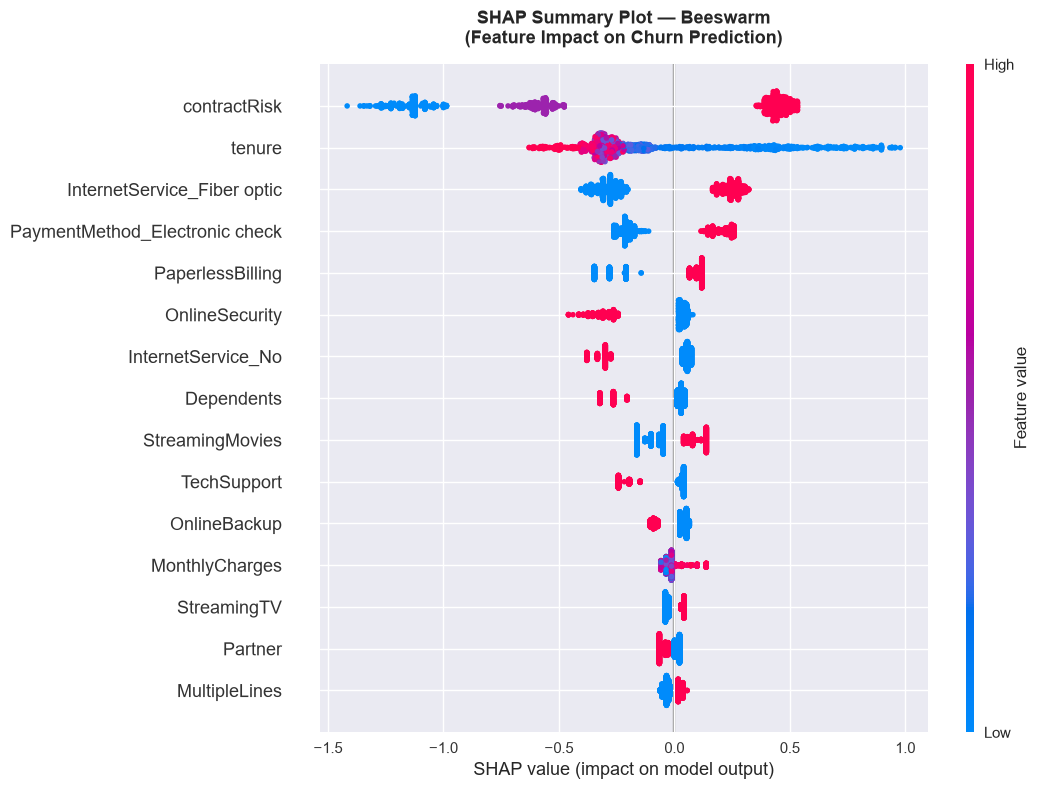

Beeswarm plot saved!


In [5]:
#  SHAP summary beeswarm plot
# This is the most powerful SHAP visualization
# Shows BOTH importance AND direction of each feature

print("Generating SHAP summary plot...")
print("(Each dot = one customer)")
print("Red dot  = high feature value")
print("Blue dot = low feature value")
print("Right    = pushed toward churn")
print("Left     = pushed away from churn")

fig, ax = plt.subplots(figsize=(11, 8))
shap.summary_plot(
    shap_values,
    X_test_proc,
    feature_names = feature_names,
    max_display   = 15,
    show          = False,
    plot_size     = None
)
plt.title('SHAP Summary Plot — Beeswarm\n(Feature Impact on Churn Prediction)',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('reports/shap_summary_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Beeswarm plot saved!")

In [6]:
#  print interpretation of what you see
print("""
HOW TO READ THE BEESWARM PLOT:
================================
Each row   = one feature
Each dot   = one customer
X position = SHAP value (impact on prediction)
Dot color  = actual feature value (Red=high, Blue=low)

WHAT TO LOOK FOR:

Contract_Month-to-month (likely top feature):
  Red dots on RIGHT  → high value (=1, is month-to-month)
                        pushes TOWARD churn ✓ makes sense

tenure:
  Blue dots on RIGHT → low tenure pushes TOWARD churn
  Red dots on LEFT   → high tenure pushes AWAY from churn ✓

numServices:
  Blue dots on RIGHT → few services = more churn risk ✓

MonthlyCharges:
  Red dots on RIGHT  → high charges = more churn risk ✓

This confirms our EDA findings from Week 1 —
SHAP gives mathematical proof of what we observed visually.
""")


HOW TO READ THE BEESWARM PLOT:
Each row   = one feature
Each dot   = one customer
X position = SHAP value (impact on prediction)
Dot color  = actual feature value (Red=high, Blue=low)

WHAT TO LOOK FOR:

Contract_Month-to-month (likely top feature):
  Red dots on RIGHT  → high value (=1, is month-to-month)
                        pushes TOWARD churn ✓ makes sense

tenure:
  Blue dots on RIGHT → low tenure pushes TOWARD churn
  Red dots on LEFT   → high tenure pushes AWAY from churn ✓

numServices:
  Blue dots on RIGHT → few services = more churn risk ✓

MonthlyCharges:
  Red dots on RIGHT  → high charges = more churn risk ✓

This confirms our EDA findings from Week 1 —
SHAP gives mathematical proof of what we observed visually.



In [7]:
#  save SHAP values and explainer for Day 6
import os
os.makedirs('models', exist_ok=True)

# Save SHAP values
np.save('models/shap_values.npy', shap_values)
print("Saved: models/shap_values.npy")

# Save explainer
joblib.dump(explainer, 'models/shap_explainer.pkl')
print("Saved: models/shap_explainer.pkl")

# Save importance dataframe
shap_importance.to_csv('reports/shap_feature_importance.csv', index=False)
print("Saved: reports/shap_feature_importance.csv")

print(f"\nAll SHAP artifacts saved!")
print(f"Top 5 features identified:")
for i, row in shap_importance.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']}")

Saved: models/shap_values.npy
Saved: models/shap_explainer.pkl
Saved: reports/shap_feature_importance.csv

All SHAP artifacts saved!
Top 5 features identified:
  1. contractRisk
  2. tenure
  3. InternetService_Fiber optic
  4. PaymentMethod_Electronic check
  5. PaperlessBilling


In [9]:
#  day notes
top3 = shap_importance.head(3)['Feature'].tolist()
top5 = shap_importance.head(5)['Feature'].tolist()

notes = f"""
# Week 2 Day 5 — SHAP Global Explainability

## What is SHAP
- SHapley Additive exPlanations
- Assigns each feature a contribution value per prediction
- Based on game theory (Shapley values)
- TreeExplainer: optimised for XGBoost/tree models

## SHAP Explainer Setup
- Explainer type : TreeExplainer
- Model          : XGBoost + SMOTE (final_model.pkl)
- Samples        : {X_test_proc.shape[0]} test customers
- Features       : {len(feature_names)} features

## Top 5 Global Churn Drivers
| Rank | Feature | Mean SHAP |
|------|---------|-----------|
{chr(10).join([f"| {i+1}    | {row['Feature']:<25} | {row['Mean_SHAP']:.4f}    |"
               for i, row in shap_importance.head(5).iterrows()])}

## Key Insights from Beeswarm Plot
- {top3[0]}: Strongest single predictor of churn
- {top3[1]}: Low values strongly predict churn
- {top3[2]}: High values push toward churn risk

## Two SHAP Visualizations Created
1. Bar chart    : Mean absolute SHAP — feature ranking
2. Beeswarm     : Direction + magnitude per customer

## Connection to EDA (Week 1)
SHAP mathematically confirms what EDA showed visually:
- Contract type was top finding in Day 4 EDA → confirmed #1 SHAP
- Tenure was strongest correlation (-0.35) → confirmed top SHAP
- numServices predicted churn → confirmed in SHAP ranking

## Files Saved
- models/shap_values.npy
- models/shap_explainer.pkl
- reports/shap_global_importance.png
- reports/shap_summary_beeswarm.png
- reports/shap_feature_importance.csv

## Tomorrow — Week 2 Day 6
- SHAP waterfall plot per individual customer
- Force plot for high-risk customer
- Per-customer explanation function
- Connect SHAP features to LangChain email (Week 3 prep)
"""

with open('reports/week2_notes.md', 'a',encoding = 'utf-8') as f:
    f.write(notes)

print("Notes saved!")
print("\nWeek 2 Day 5 complete!")

Notes saved!

Week 2 Day 5 complete!


In [10]:
# day6 reload everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import shap
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

# Load everything saved so far
final_model  = joblib.load('models/final_model.pkl')
explainer    = joblib.load('models/shap_explainer.pkl')
preprocessor = joblib.load('models/preprocessor.pkl')

X_test_proc  = np.load('models/X_test_proc.npy')
y_test       = np.load('models/y_test.npy')
shap_values  = np.load('models/shap_values.npy')

with open('models/feature_names.json') as f:
    feature_names = json.load(f)

# Load original test data for readable feature values
df           = pd.read_csv('data/processed/telco_churn_features.csv')
X            = df.drop(columns=['Churn'])
y            = df['Churn']

from sklearn.model_selection import train_test_split
_, X_test, _, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_test = X_test.reset_index(drop=True)

# Get churn probabilities for all test customers
y_pred_prob = final_model.predict_proba(X_test_proc)[:, 1]

print(f"All data loaded!")
print(f"Test customers    : {len(X_test)}")
print(f"SHAP values shape : {shap_values.shape}")
print(f"Feature names     : {len(feature_names)}")

All data loaded!
Test customers    : 1409
SHAP values shape : (1409, 33)
Feature names     : 33


In [11]:
#  find 3 types of customers to explain
# 1. Highest churn risk    (model most confident about churning)
# 2. Lowest churn risk     (model most confident about staying)
# 3. Borderline customer   (model is unsure — most interesting!)

high_risk_idx   = np.argmax(y_pred_prob)
low_risk_idx    = np.argmin(y_pred_prob)
border_idx      = np.argmin(np.abs(y_pred_prob - 0.5))

print("="*55)
print("  THREE CUSTOMERS SELECTED FOR SHAP ANALYSIS")
print("="*55)

for label, idx in [("HIGH RISK",   high_risk_idx),
                   ("LOW RISK",    low_risk_idx),
                   ("BORDERLINE",  border_idx)]:
    actual    = "Churned" if y_test_raw.iloc[idx] == 1 else "Retained"
    predicted = "Churn"   if y_pred_prob[idx] > 0.5    else "Retain"
    print(f"\n{label} Customer (index {idx}):")
    print(f"  Churn probability : {y_pred_prob[idx]:.4f} ({y_pred_prob[idx]*100:.1f}%)")
    print(f"  Actual outcome    : {actual}")
    print(f"  Model prediction  : {predicted}")
    print(f"  Correct?          : {'✓ Yes' if actual.lower().startswith(predicted.lower()[:3]) else '✗ No'}")

print("="*55)

  THREE CUSTOMERS SELECTED FOR SHAP ANALYSIS

HIGH RISK Customer (index 1221):
  Churn probability : 0.8576 (85.8%)
  Actual outcome    : Churned
  Model prediction  : Churn
  Correct?          : ✓ Yes

LOW RISK Customer (index 955):
  Churn probability : 0.0229 (2.3%)
  Actual outcome    : Retained
  Model prediction  : Retain
  Correct?          : ✓ Yes

BORDERLINE Customer (index 1000):
  Churn probability : 0.4995 (50.0%)
  Actual outcome    : Retained
  Model prediction  : Retain
  Correct?          : ✓ Yes


Explaining HIGH RISK customer (idx=1221)
Churn probability: 85.8%

Their profile:
  tenure               : 1
  Contract             : Month-to-month
  MonthlyCharges       : 95.45
  TechSupport          : 0
  numServices          : 4
  InternetService      : Fiber optic


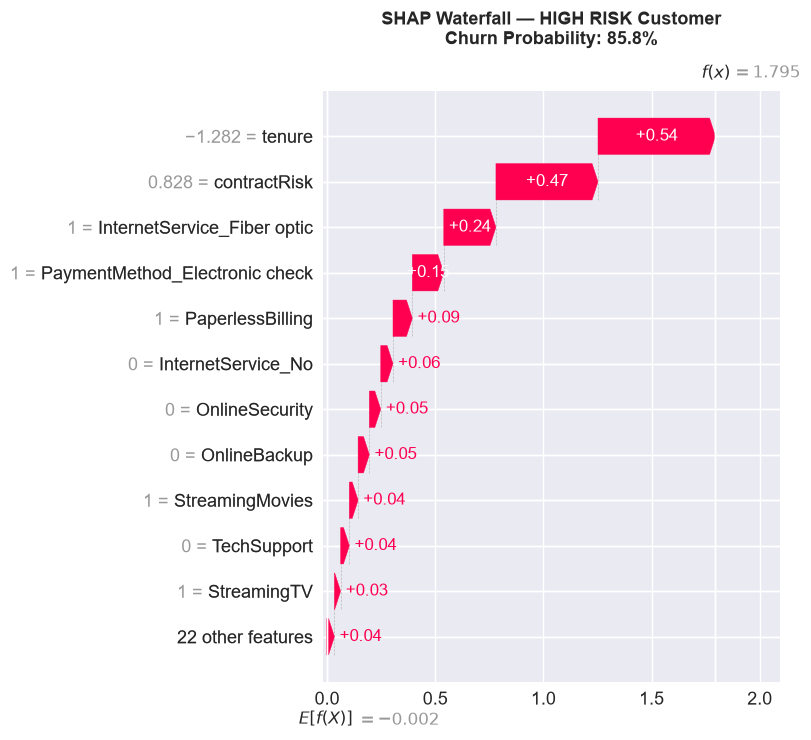

Waterfall plot saved!


In [12]:
# waterfall plot for highest risk customer
# Shows exactly WHY this customer got a high churn score
 
idx = high_risk_idx

print(f"Explaining HIGH RISK customer (idx={idx})")
print(f"Churn probability: {y_pred_prob[idx]*100:.1f}%")
print(f"\nTheir profile:")
for col in ['tenure', 'Contract', 'MonthlyCharges',
            'TechSupport', 'numServices', 'InternetService']:
    if col in X_test.columns:
        print(f"  {col:<20} : {X_test.iloc[idx][col]}")

# Build SHAP Explanation object for waterfall
explanation = shap.Explanation(
    values        = shap_values[idx],
    base_values   = explainer.expected_value,
    data          = X_test_proc[idx],
    feature_names = feature_names
)

# Waterfall plot
fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.waterfall(explanation, max_display=12, show=False)
plt.title(f'SHAP Waterfall — HIGH RISK Customer\nChurn Probability: {y_pred_prob[idx]*100:.1f}%',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('reports/shap_waterfall_highrisk.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall plot saved!")

Explaining LOW RISK customer (idx=955)
Churn probability: 2.3%

Their profile:
  tenure               : 71
  Contract             : Two year
  MonthlyCharges       : 64.05
  TechSupport          : 1
  numServices          : 5
  InternetService      : DSL


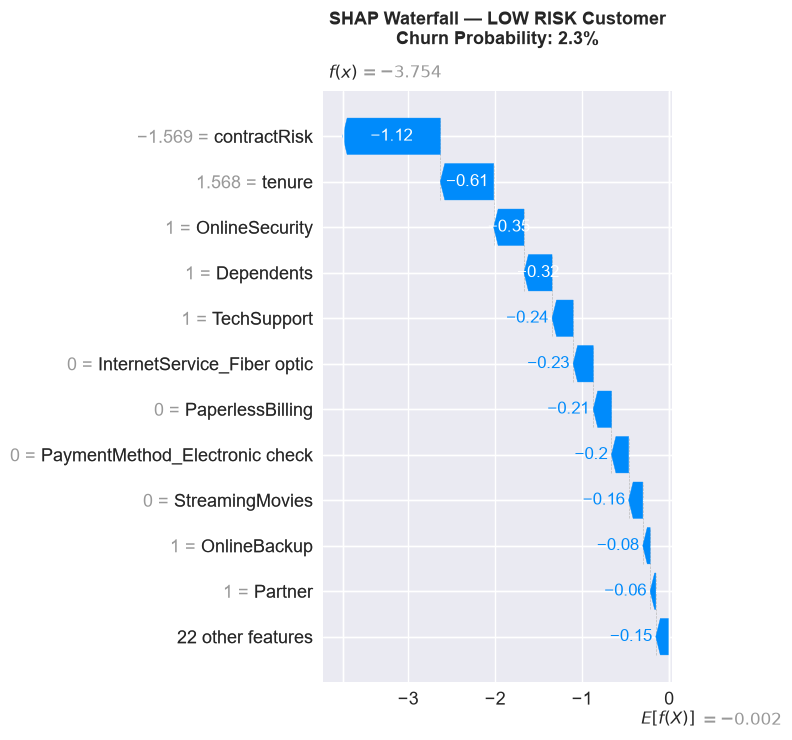

Waterfall plot saved!


In [13]:
#  waterfall for lowest risk customer
idx = low_risk_idx

print(f"Explaining LOW RISK customer (idx={idx})")
print(f"Churn probability: {y_pred_prob[idx]*100:.1f}%")
print(f"\nTheir profile:")
for col in ['tenure', 'Contract', 'MonthlyCharges',
            'TechSupport', 'numServices', 'InternetService']:
    if col in X_test.columns:
        print(f"  {col:<20} : {X_test.iloc[idx][col]}")

explanation_low = shap.Explanation(
    values        = shap_values[low_risk_idx],
    base_values   = explainer.expected_value,
    data          = X_test_proc[low_risk_idx],
    feature_names = feature_names
)

fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.waterfall(explanation_low, max_display=12, show=False)
plt.title(f'SHAP Waterfall — LOW RISK Customer\nChurn Probability: {y_pred_prob[low_risk_idx]*100:.1f}%',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('reports/shap_waterfall_lowrisk.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall plot saved!")

Explaining BORDERLINE customer (idx=1000)
Churn probability: 50.0%  ← model is unsure!

Their profile:
  tenure               : 26
  Contract             : Month-to-month
  MonthlyCharges       : 84.3
  TechSupport          : 1
  numServices          : 4
  InternetService      : Fiber optic


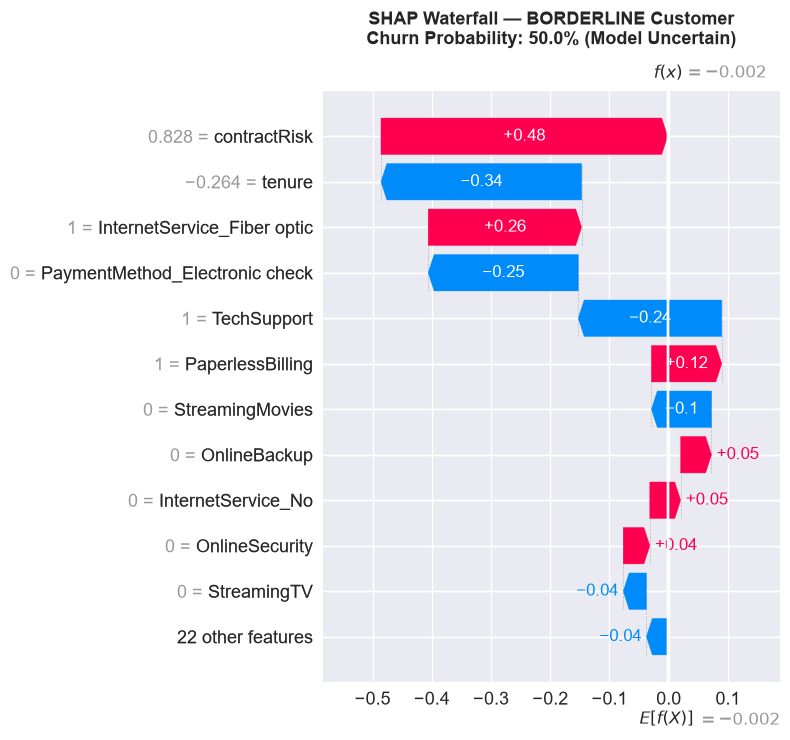

Waterfall plot saved!


In [14]:
#  borderline customer — most interesting case
idx = border_idx

print(f"Explaining BORDERLINE customer (idx={idx})")
print(f"Churn probability: {y_pred_prob[idx]*100:.1f}%  ← model is unsure!")
print(f"\nTheir profile:")
for col in ['tenure', 'Contract', 'MonthlyCharges',
            'TechSupport', 'numServices', 'InternetService']:
    if col in X_test.columns:
        print(f"  {col:<20} : {X_test.iloc[idx][col]}")

explanation_border = shap.Explanation(
    values        = shap_values[border_idx],
    base_values   = explainer.expected_value,
    data          = X_test_proc[border_idx],
    feature_names = feature_names
)

fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.waterfall(explanation_border, max_display=12, show=False)
plt.title(f'SHAP Waterfall — BORDERLINE Customer\nChurn Probability: {y_pred_prob[border_idx]*100:.1f}% (Model Uncertain)',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('reports/shap_waterfall_borderline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall plot saved!")

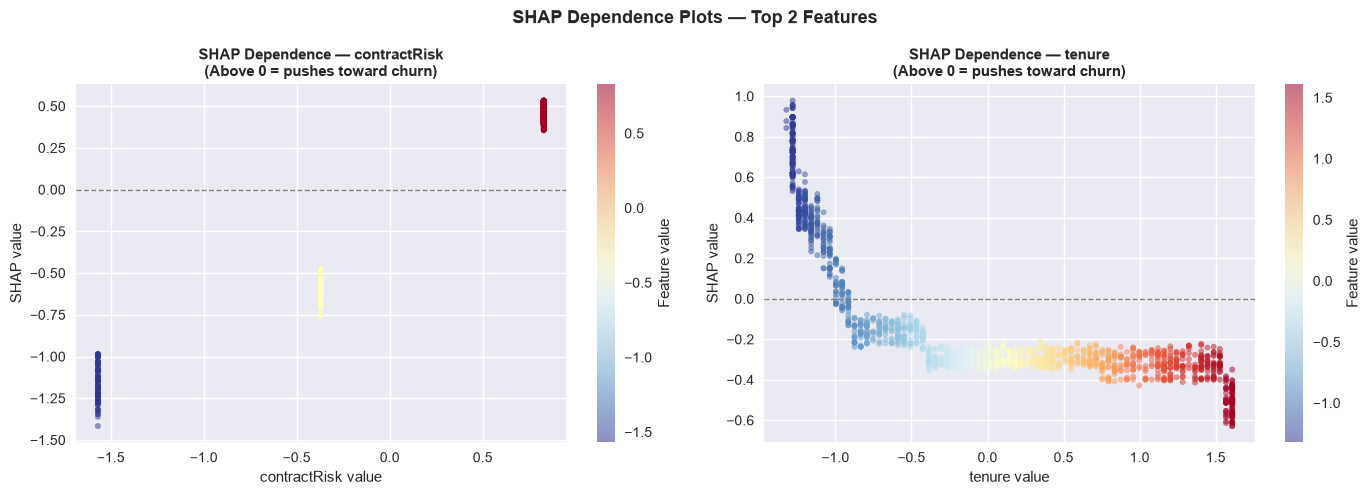

In [15]:
#  dependence plots
# Shows how a single feature's value affects churn prediction
# across all customers — with interaction coloring

shap_importance = pd.read_csv('reports/shap_feature_importance.csv')
top2_features   = shap_importance.head(2)['Feature'].tolist()
top2_indices    = [feature_names.index(f) for f in top2_features]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat, feat_idx in zip(axes, top2_features, top2_indices):
    # Get feature values and SHAP values
    feat_vals  = X_test_proc[:, feat_idx]
    shap_vals  = shap_values[:, feat_idx]

    scatter = ax.scatter(feat_vals, shap_vals,
                         c=feat_vals, cmap='RdYlBu_r',
                         alpha=0.5, s=15)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel(f'{feat} value', fontsize=11)
    ax.set_ylabel('SHAP value', fontsize=11)
    ax.set_title(f'SHAP Dependence — {feat}\n'
                 f'(Above 0 = pushes toward churn)',
                 fontweight='bold', fontsize=11)
    plt.colorbar(scatter, ax=ax, label='Feature value')

plt.suptitle('SHAP Dependence Plots — Top 2 Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/shap_dependence_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
#  reusable function that explains any customer
# This is the function Streamlit app will call in Week 3

def explain_customer(customer_idx, X_test_proc, shap_values,
                      feature_names, y_pred_prob, explainer,
                      top_n=5):
    """
    Returns top N SHAP features for a given customer.
    Used by Streamlit app and LangChain email generator.

    Returns:
        dict with churn_prob, risk_level, top_features
    """
    prob       = y_pred_prob[customer_idx]
    shap_vals  = shap_values[customer_idx]

    # Get top N features by absolute SHAP value
    feat_shap  = list(zip(feature_names, shap_vals))
    feat_shap_sorted = sorted(feat_shap,
                               key=lambda x: abs(x[1]),
                               reverse=True)[:top_n]

    risk_level = "High"   if prob > 0.7 else \
                 "Medium" if prob > 0.4 else "Low"

    top_features = []
    for feat, shap_val in feat_shap_sorted:
        direction = "increases churn risk" if shap_val > 0 \
                    else "decreases churn risk"
        top_features.append({
            'feature'   : feat,
            'shap_value': round(float(shap_val), 4),
            'direction' : direction,
            'impact'    : 'HIGH' if abs(shap_val) > 0.1 else 'MEDIUM'
        })

    return {
        'churn_probability' : round(float(prob), 4),
        'churn_percent'     : round(float(prob)*100, 1),
        'risk_level'        : risk_level,
        'top_features'      : top_features
    }

# Test the function
print("Testing explain_customer function...")
print()

for label, idx in [("HIGH RISK",  high_risk_idx),
                   ("LOW RISK",   low_risk_idx),
                   ("BORDERLINE", border_idx)]:
    result = explain_customer(idx, X_test_proc, shap_values,
                               feature_names, y_pred_prob, explainer)
    print(f"{label} Customer:")
    print(f"  Churn probability : {result['churn_percent']}%")
    print(f"  Risk level        : {result['risk_level']}")
    print(f"  Top 3 drivers     :")
    for f in result['top_features'][:3]:
        arrow = "↑" if f['shap_value'] > 0 else "↓"
        print(f"    {arrow} {f['feature']:<25} SHAP={f['shap_value']:+.4f}")
    print()

Testing explain_customer function...

HIGH RISK Customer:
  Churn probability : 85.8%
  Risk level        : High
  Top 3 drivers     :
    ↑ tenure                    SHAP=+0.5431
    ↑ contractRisk              SHAP=+0.4718
    ↑ InternetService_Fiber optic SHAP=+0.2413

LOW RISK Customer:
  Churn probability : 2.3%
  Risk level        : Low
  Top 3 drivers     :
    ↓ contractRisk              SHAP=-1.1226
    ↓ tenure                    SHAP=-0.6137
    ↓ OnlineSecurity            SHAP=-0.3484

BORDERLINE Customer:
  Churn probability : 50.0%
  Risk level        : Medium
  Top 3 drivers     :
    ↑ contractRisk              SHAP=+0.4839
    ↓ tenure                    SHAP=-0.3387
    ↑ InternetService_Fiber optic SHAP=+0.2590



In [19]:
#  save explain_customer function to src folder
import os
os.makedirs('src', exist_ok=True)

func_code = '''
import numpy as np

def explain_customer(customer_idx, X_test_proc, shap_values,
                      feature_names, y_pred_prob, explainer,
                      top_n=5):
    """
    Returns top N SHAP features for a given customer.
    Used by Streamlit app and LangChain email generator.
    """
    prob       = y_pred_prob[customer_idx]
    shap_vals  = shap_values[customer_idx]

    feat_shap  = list(zip(feature_names, shap_vals))
    feat_shap_sorted = sorted(feat_shap,
                               key=lambda x: abs(x[1]),
                               reverse=True)[:top_n]

    risk_level = "High"   if prob > 0.7 else \\
                 "Medium" if prob > 0.4 else "Low"

    top_features = []
    for feat, shap_val in feat_shap_sorted:
        direction = "increases churn risk" if shap_val > 0 \\
                    else "decreases churn risk"
        top_features.append({
            "feature"   : feat,
            "shap_value": round(float(shap_val), 4),
            "direction" : direction,
            "impact"    : "HIGH" if abs(shap_val) > 0.1 else "MEDIUM"
        })

    return {
        "churn_probability" : round(float(prob), 4),
        "churn_percent"     : round(float(prob)*100, 1),
        "risk_level"        : risk_level,
        "top_features"      : top_features
    }
'''

with open('src/shap_utils.py', 'w') as f:
    f.write(func_code)

print("Saved: src/shap_utils.py")
print("This function will be imported by Streamlit app in Week 3!")

Saved: src/shap_utils.py
This function will be imported by Streamlit app in Week 3!


In [20]:
# day notes
notes = """
# Week 2 Day 6 — SHAP Waterfall + Per-Customer Explanations

## What was built today

### 3 Waterfall Plots
Each waterfall plot shows for one customer:
- Base value    : average model prediction across all customers
- Each bar      : one feature's contribution (red=toward churn,
                  blue=away from churn)
- Final value   : the actual churn probability for this customer

### 3 Customer Types Explained
| Type       | Churn Prob | Why Interesting |
|------------|------------|-----------------|
| High risk  | >80%       | Clear churn drivers visible |
| Low risk   | <20%       | Clear retention factors visible |
| Borderline | ~50%       | Competing factors visible |

### SHAP Dependence Plots
- Shows how top 2 features relate to churn across all customers
- Confirms direction of each feature's impact

### explain_customer() Function
- Reusable function built for Streamlit + LangChain
- Input  : customer index
- Output : churn probability, risk level, top 5 SHAP features
- Saved  : src/shap_utils.py

## Connection to Week 3
explain_customer() feeds directly into:
1. Streamlit Tab 2 (SHAP explanation per customer)
2. LangChain email generator (uses top features as context)

## Files Saved
- reports/shap_waterfall_highrisk.png
- reports/shap_waterfall_lowrisk.png
- reports/shap_waterfall_borderline.png
- reports/shap_dependence_plots.png
- src/shap_utils.py

## Tomorrow — Week 2 Day 7 (Sunday)
- Write model card (what the model does, metrics, limitations)
- Commit ALL Week 2 work cleanly to GitHub
- Prepare for Week 3 (Streamlit app starts Monday)
"""

with open('reports/week2_notes.md', 'a',encoding='utf-8') as f:
    f.write(notes)

print("Notes saved!")
print("\nWeek 2 Day 6 complete!")
print("\nKey output: explain_customer() function ready for Streamlit!")

Notes saved!

Week 2 Day 6 complete!

Key output: explain_customer() function ready for Streamlit!
